# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
!pip install -q --index-url https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple group24-25739083==2025.0.1.0

# Import custom package (group24_25739083)
from group24_25739083.data.sets import pop_target, split_sets_random, split_sets_by_time
from group24_25739083.data.io import save_sets, load_sets, save_pickle, load_pickle
from group24_25739083.features.encoding import (
    fit_onehot_for_regression, transform_onehot_for_regression,
    fit_ordinal_for_tree, transform_ordinal_for_tree
)
from group24_25739083.features.scaling import fit_standard_scaler, transform_with_scaler
from group24_25739083.features.outliers import cap_outliers_by_quantiles
from group24_25739083.models.classification import threshold_tune, predict_with_threshold
from group24_25739083.models.performance import evaluate_classification
from group24_25739083.models.importance import get_lr_coefficients, get_rf_importances, get_xgb_importances

In [4]:
# <Student to fill this section>

# Standard libraries
from pathlib import Path
import os
import re
import joblib
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Optional

# Visualization
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Engineering
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import chi2, f_classif
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.impute import SimpleImputer

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

# Gradient Boosting
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Utilities
from joblib import dump

---
## A. Project Description


In [5]:
# <Student to fill this section>
student_name = "Manh Tuan Nguyen"
student_id = "25739083"
group_id = "24"

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [8]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [9]:
# <Student to fill this section>
business_use_case_description = """
Predict draft probabilities for each player to help NBA front offices rank prospects, focus scouting, and plan draft scenarios - optimized for AUROC and explainability.
"""

**Business Use Case — NBA Draft Probability Scoring**

**Goal**  
Build a machine-learning system that predicts the probability (0-1) that a college/international player will be drafted in the upcoming NBA draft using season statistics and contextual features. The model outputs a calibrated score `drafted` per `player_id`.


In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
# <Student to fill this section>
business_objectives = """
Accurate predictions increase hit rate and efficiency; incorrect ones cause overdrafts or missed talent, so we manage risk with thresholds, cost-aware rules, calibration, monitoring, and human review.
"""

**Business Objectives — Impact of Accurate vs. Incorrect Results**

**Impact when predictions are accurate**  
- Higher hit rate on selections and undrafted signings, improving roster value and on-court performance.  
- More efficient scouting allocation by focusing live looks on high-probability prospects.  
- Faster decision cycles with clearer justification from explanations and calibration.  
- Better trade planning by trusting ranked boards and scenario outcomes.

**Impact when predictions are incorrect**  
- False positives (overdraft): wasted picks, cap inefficiency, opportunity cost of bypassed players.  
- False negatives (missed talent): loss of surplus value to competitors, reduced upside, fan and stakeholder disappointment.  
- Miscalibration: overconfidence leads to premature lock-in; underconfidence delays action and wastes time.  
- Data drift or leakage: silent degradation of decisions across seasons or segments.

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Stakeholders across front office, scouting, analytics, coaching, and operations use drafted probabilities keyed by player_id to rank prospects, plan decisions, and document rationale, with explanations, thresholds, and monitoring to mitigate bias, drift, and overreliance.
"""

**Use of Predictions, Users, and Impact Overview**

**Who will use the predictions**  
- **Front office / GM:** maintain the board, set `prob_threshold`, and evaluate trade scenarios.  
- **Scouting leadership:** plan live looks and workouts; request deep dives for high-variance players; log overrides.  
- **Analytics team:** train, validate, calibrate, explain, and monitor the model; publish model cards.  
- **Coaching staff:** assess role fit and lineup impact using explanatory artifacts.  
- **Finance / operations:** run roster-cap and contract scenarios driven by predicted outcomes.

**Who is impacted**  
Players and agents (evaluation outcomes), coaches and teammates (roles and minutes), ownership and fans (team performance), and league partners (competitive integrity).

In [14]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [15]:
# <Student to fill this section>

# Set base path
base_path = "../../data/raw"

# Load datasets
train_df = pd.read_csv(os.path.join(base_path, "train.csv"), encoding="utf-8")
test_df = pd.read_csv(os.path.join(base_path, "test.csv"), encoding="utf-8")
sample_submission_df = pd.read_csv(os.path.join(base_path, "sample_submission.csv"), encoding="utf-8")
metadata_df = pd.read_csv(os.path.join(base_path, "metadata.csv"), encoding="cp1252")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample Submission shape:", sample_submission_df.shape)
print("Metadata shape:", metadata_df.shape)

Train shape: (14774, 62)
Test shape: (1297, 61)
Sample Submission shape: (1297, 2)
Metadata shape: (62, 3)


### C.2 Define Target variable

In [16]:
# <Student to fill this section>

datasets = {
    "TRAIN": train_df,
    "TEST": test_df,
    "SAMPLE_SUBMISSION": sample_submission_df,
    "METADATA": metadata_df
}

for name, df in datasets.items():
    print(f"\n===== {name} =====")
    print(df.info())
    display(df.head())


===== TRAIN =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 62 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   team                 14774 non-null  object 
 1   conf                 14774 non-null  object 
 2   GP                   14774 non-null  int64  
 3   Min_per              14774 non-null  float64
 4   Ortg                 14774 non-null  float64
 5   usg                  14774 non-null  float64
 6   eFG                  14774 non-null  float64
 7   TS_per               14774 non-null  float64
 8   ORB_per              14774 non-null  float64
 9   DRB_per              14774 non-null  float64
 10  AST_per              14774 non-null  float64
 11  TO_per               14774 non-null  float64
 12  FTM                  14774 non-null  int64  
 13  FTA                  14774 non-null  int64  
 14  FT_per               14774 non-null  float64
 15  twoPM            

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0
3,Virginia,ACC,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,...,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0
4,Elon,SC,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,...,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,a962c41c-55ff-461e-8585-db32e4fa0580,0.0



===== TEST =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 61 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   team                 1297 non-null   object 
 1   conf                 1297 non-null   object 
 2   GP                   1297 non-null   int64  
 3   Min_per              1297 non-null   float64
 4   Ortg                 1297 non-null   float64
 5   usg                  1297 non-null   float64
 6   eFG                  1297 non-null   float64
 7   TS_per               1297 non-null   float64
 8   ORB_per              1297 non-null   float64
 9   DRB_per              1297 non-null   float64
 10  AST_per              1297 non-null   float64
 11  TO_per               1297 non-null   float64
 12  FTM                  1297 non-null   int64  
 13  FTA                  1297 non-null   int64  
 14  FT_per               1297 non-null   float64
 15  twoPM               

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id
0,UC Davis,BW,8,2.2,51.7,13.4,30.0,30.00,0.0,14.3,...,-11.240100,-4.721030,0.1000,0.6000,0.7000,0.2000,0.1000,0.0000,1.5000,c6d3ce49-28b6-4756-8061-b2bd68730c52
1,Campbell,BSth,25,16.4,85.0,25.2,50.0,52.10,2.0,11.8,...,-2.972020,-1.741870,0.1481,0.9259,1.0741,0.1481,0.4074,0.1111,4.0741,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5
2,Weber St.,BSky,29,50.5,117.8,16.8,61.8,59.77,12.3,17.1,...,0.739055,-0.259202,2.1562,2.7500,4.9062,0.7188,0.4062,1.0625,6.7500,0cf3e822-9446-4285-b7ed-7c19d8e976fe
3,Ohio,MAC,17,14.9,85.8,13.1,34.9,34.88,5.1,13.7,...,-3.339750,-0.573442,0.5789,1.5789,2.1579,0.5263,0.1579,0.1579,2.6842,b1a88de0-6852-4597-bb92-9164b40758e5
4,New Mexico St.,WAC,26,17.1,85.8,10.8,48.1,49.46,5.6,17.4,...,-4.184970,1.718210,0.4643,1.1429,1.6071,0.1071,0.0714,0.4286,1.7500,97c327ce-d051-40f0-9166-1a43557c3c92



===== SAMPLE_SUBMISSION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   player_id  1297 non-null   object 
 1   drafted    1297 non-null   float64
dtypes: float64(1), object(1)
memory usage: 20.4+ KB
None


,player_id,drafted
0,c6d3ce49-28b6-4756-8061-b2bd68730c52,0.51
1,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5,0.92
2,0cf3e822-9446-4285-b7ed-7c19d8e976fe,0.14
3,b1a88de0-6852-4597-bb92-9164b40758e5,0.71
4,97c327ce-d051-40f0-9166-1a43557c3c92,0.60



===== METADATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   feature      62 non-null     int64 
 1   name         62 non-null     object
 2   description  62 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None


,feature,name,description
0,1,team,Name of team
1,2,conf,Name of conference
2,3,GP,Games played
3,4,Min_per,Player's percentage of available team minutes ...
4,5,ORtg,ORtg - Offensive Rating (available since the 1...


In [17]:
# <Student to fill this section>
target_definition_explanations = """
Explain the rationale on the definition of the target variable according to your business use case.
"""

**Target definition**  
`drafted` is a binary label at the player-season level keyed by `player_id`. We set `drafted = 1` if the player was selected in the NBA Draft (round 1 or round 2) in the corresponding `year`; otherwise `drafted = 0`.

**Rationale**  
The business decision we support is whether to invest a draft pick in a player now. A label tied strictly to draft selection (not later free-agent outcomes) aligns with that decision, is observable on draft night, and avoids post-draft leakage.

**Labeling rules**  
- Selected with any pick in round 1 or 2 in that `year` -> `drafted = 1`.  
- Not selected (including two-way signings, Exhibit 10s, summer league invites, or later conversions) -> `drafted = 0`.  
- If a player appears in multiple seasons, the label reflects the outcome of that specific season only.  
- International stash picks count as drafted if selected; those not selected remain `0`.

In [18]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [19]:
# <Student to fill this section>

target_name = "drafted"

### C.4 Explore Target variable

In [20]:
# <Student to fill this section>

# Class balance overview
value_counts = train_df[target_name].value_counts().sort_index()
proportions = (value_counts / len(train_df)).round(4)
print("\nClass distribution (count):")
print(value_counts.to_string())
print("\nClass distribution (proportion):")
print(proportions.to_string())


Class distribution (count):
drafted
0.0    14656
1.0      118

Class distribution (proportion):
drafted
0.0    0.992
1.0    0.008


**Target distribution**  

The target `drafted` is extremely imbalanced: 118 positives vs 14656 negatives (0.8 % prevalence). This has major implications for model training, validation stability, and decision thresholds.

**Counts and rates**  
- Total observations: 14774  
- Positives (`drafted = 1`): 118  
- Negatives (`drafted = 0`): 14656  
- Class proportion: 0.008 vs 0.992  
- Naive baseline: predicting all zeros yields ~99.2 % accuracy but zero recall for the positive class.

**Implications for modeling**  
- Default thresholds (0.5) are unsuitable; the score distribution will be highly skewed toward low values.  
- With an 80/20 split, the validation set contains only ~24 positives, so variance of precision/recall is high.  
- Class imbalance will bias many learners toward the majority; set `class_weight='balanced'` for linear and tree models and use `scale_pos_weight ~= 14656/118 ~ 124` for gradient boosting (e.g., XGBoost).  
- Consider train-fold-only resampling (e.g., SMOTE or under-sampling) to aid minority learning, but never apply on validation or test.

**Mitigations and plan**  
- Use stratified, year-aware cross-validation; ensure each fold has sufficient positives.  
- Tune decision rules via `prob_threshold` and top-K lists; review borderline cases with human-in-the-loop.  
- Apply class weighting and (optionally) fold-only resampling; perform probability calibration.  
- Track `AUROC`, PR AUC, `precision@K`, `recall@K`, calibration error, and drift metrics; log decisions by `player_id`.


In [21]:
# <Student to fill this section>
target_distribution_explanations = """
Target is highly imbalanced (0.8 % drafted), so optimize with stratified CV, class weighting (scale_pos_weight ~ 124), calibrated thresholds or top-K, PR-focused metrics, and train-only resampling to avoid misleading 99.2 % baseline accuracy.
"""

In [22]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest - `numerical features`

In [23]:
# <Student to fill this section>

In [24]:
# Basketball-standard rename map (snake_case)
rename_map = {
    # Identifiers / categoricals
    "player_id": "player_id",
    "team": "team",
    "conf": "conference",
    "yr": "class_year",
    "ht": "height",
    "type": "dataset_type",

    # Core counting stats
    "GP": "games_played",
    "mp": "minutes_played",
    "pts": "points",
    "ast": "assists",
    "stl": "steals",
    "blk": "blocks",
    "oreb": "offensive_rebounds",
    "dreb": "defensive_rebounds",
    "treb": "total_rebounds",

    # Percent-of-team / rate stats
    "Min_per": "min_pct",            # % of team minutes (Min%)
    "usg": "usage_pct",              # Usage %
    "eFG": "efg_pct",                # Effective FG%
    "TS_per": "ts_pct",              # True Shooting %
    "ORB_per": "orb_pct",            # Offensive Rebound %
    "DRB_per": "drb_pct",            # Defensive Rebound %
    "AST_per": "ast_pct",            # Assist %
    "TO_per": "tov_pct",             # Turnover %
    "blk_per": "blk_pct",            # Block %
    "stl_per": "stl_pct",            # Steal %

    # Free throws
    "FTM": "ftm",                    # FT made
    "FTA": "fta",                    # FT att
    "FT_per": "ft_pct",              # FT%

    # 2PT shooting
    "twoPM": "fg2m",                 # 2PT made
    "twoPA": "fg2a",                 # 2PT att
    "twoP_per": "fg2_pct",           # 2PT%

    # 3PT shooting
    "TPM": "fg3m",                   # 3PT made
    "TPA": "fg3a",                   # 3PT att
    "TP_per": "fg3_pct",             # 3PT%

    # Shot profile (rim / mid / dunks)
    "rimmade": "rim_fg_made",
    "rimmade_rimmiss": "rim_fg_att", # made + miss = attempts
    "midmade": "mid_fg_made",
    "midmade_midmiss": "mid_fg_att",
    "rim_ratio": "rim_shot_ratio",   # share of FGA at rim
    "mid_ratio": "mid_shot_ratio",   # share of FGA midrange
    "dunksmade": "dunks_made",
    "dunksmiss_dunksmade": "dunks_att",
    "dunks_ratio": "dunk_rate",

    # Efficiency / ratings
    "Ortg": "off_rating",            # Offensive Rating (per 100 poss)
    "drtg": "def_rating",            # Defensive Rating (per 100 poss)
    "adrtg": "adj_def_rating",       # Adjusted Defensive Rating (source-specific)
    "adjoe": "adj_off_eff",          # Adjusted Offensive Efficiency (source-specific)
    "ftr": "free_throw_rate",        # FTr = FTA/FGA (team/player definition per source)

    # Misc advanced (source-specific naming harmonized)
    "porpag": "porpag",              # Points Over Replacement per Adjusted Game
    "dporpag": "def_porpag",         # Defensive PORPAG (assumed)
    "stops": "def_stops",            # Defensive stops
    "bpm": "box_plus_minus",
    "obpm": "off_box_plus_minus",
    "dbpm": "def_box_plus_minus",
    "gbpm": "game_box_plus_minus",   # source-specific; overall "gBPM"
    "ogbpm": "off_game_box_plus_minus",
    "dgbpm": "def_game_box_plus_minus",

    # Other
    "year": "season_year",
    "Rec_Rank": "recruit_rank",
    "ast_tov": "ast_tov_ratio",
    "pfr": "personal_foul_rate"      # assumed; confirm with data dictionary
}

def apply_standard_names(df):
    # Only rename keys that are present to avoid KeyErrors
    cols_present = {k: v for k, v in rename_map.items() if k in df.columns}
    return df.rename(columns=cols_present)

# Example usage
train_df = apply_standard_names(train_df)
test_df  = apply_standard_names(test_df)

In [25]:
# Define preferred column order by grouping them into logical categories
preferred_order = [
    # Identifiers
    'player_id', 'team', 'team_draft_segment', 'conference', 'season_year', 'height', 'height_in_cm', 'recruit_rank', 'class_year', 'dataset_type',

    # Game participation
    'games_played', 'min_pct', 'minutes_played',

    # Free throws
    'fta', 'ftm', 'ft_pct', 'free_throw_rate',

    # 2-point field goals
    'fg2a', 'fg2m', 'fg2_pct',

    # 3-point field goals
    'fg3a', 'fg3m', 'fg3_pct',

    # Shooting efficiency
    'efg_pct', 'ts_pct',

    # Shot zones
    'rim_fg_made', 'rim_fg_att', 'rim_shot_ratio',
    'mid_fg_made', 'mid_fg_att', 'mid_shot_ratio',
    'dunks_made', 'dunks_att', 'dunk_rate',

    # Usage and offensive/defensive efficiency
    'usage_pct', 'off_rating', 'adj_off_eff', 'porpag', 'def_porpag', 'personal_foul_rate', 'ast_tov_ratio',

    # Defensive metrics
    'def_rating', 'adj_def_rating', 'def_stops',

    # BPM metrics
    'box_plus_minus', 'off_box_plus_minus', 'def_box_plus_minus', 'game_box_plus_minus', 'off_game_box_plus_minus', 'def_game_box_plus_minus',

    # Box stats
    'points', 'assists', 'steals', 'blocks', 'offensive_rebounds', 'defensive_rebounds', 'total_rebounds',

    # Percentages
    'orb_pct', 'drb_pct', 'ast_pct', 'tov_pct', 'blk_pct', 'stl_pct',
]

# For train_df, optionally add target column 'drafted'
train_columns = preferred_order + ['drafted'] if 'drafted' in train_df.columns else preferred_order
train_columns = [col for col in train_columns if col in train_df.columns]
train_df = train_df[train_columns]

# For test_df (no 'drafted' expected)
test_columns = [col for col in preferred_order if col in test_df.columns]
test_df = test_df[test_columns]

# Confirmation
print("train_df columns reordered:", train_df.shape)
print("test_df columns reordered:", test_df.shape)
print("train_df columns:", train_df.info())

train_df columns reordered: (14774, 62)
test_df columns reordered: (1297, 61)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 62 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   player_id                14774 non-null  object 
 1   team                     14774 non-null  object 
 2   conference               14774 non-null  object 
 3   season_year              14774 non-null  int64  
 4   height                   14766 non-null  object 
 5   recruit_rank             4889 non-null   float64
 6   class_year               14774 non-null  object 
 7   dataset_type             14774 non-null  object 
 8   games_played             14774 non-null  int64  
 9   min_pct                  14774 non-null  float64
 10  minutes_played           14773 non-null  float64
 11  fta                      14774 non-null  int64  
 12  ftm                      14774 non-null  int64  
 13

In [26]:
# Get list of numerical features (excluding ID and target)
numerical_features = train_df.select_dtypes(include=['int64', 'float64']).columns
numerical_features = [col for col in numerical_features if col not in ['drafted', 'player_id']]

# Create separate descriptive statistics
desc_total_train = train_df[numerical_features].describe().T.round(2)
desc_total_test = test_df[numerical_features].describe().T.round(2)
desc_drafted_train = train_df[train_df['drafted'] == 1][numerical_features].describe().T.round(2)
desc_undrafted_train = train_df[train_df['drafted'] == 0][numerical_features].describe().T.round(2)

# Display each table
print("Numerical features lists: ", numerical_features)

print("Descriptive Statistics for All Players (Total) in Training Sets:")
display(desc_total_train)

print("Descriptive Statistics for Drafted Players:")
display(desc_drafted_train)

print("Descriptive Statistics for Undrafted Players:")
display(desc_undrafted_train)

print("Descriptive Statistics for All Players (Total) in Test Sets:")
display(desc_total_test)

Numerical features lists:  ['season_year', 'recruit_rank', 'games_played', 'min_pct', 'minutes_played', 'fta', 'ftm', 'ft_pct', 'free_throw_rate', 'fg2a', 'fg2m', 'fg2_pct', 'fg3a', 'fg3m', 'fg3_pct', 'efg_pct', 'ts_pct', 'rim_fg_made', 'rim_fg_att', 'rim_shot_ratio', 'mid_fg_made', 'mid_fg_att', 'mid_shot_ratio', 'dunks_made', 'dunks_att', 'dunk_rate', 'usage_pct', 'off_rating', 'adj_off_eff', 'porpag', 'def_porpag', 'personal_foul_rate', 'ast_tov_ratio', 'def_rating', 'adj_def_rating', 'def_stops', 'box_plus_minus', 'off_box_plus_minus', 'def_box_plus_minus', 'game_box_plus_minus', 'off_game_box_plus_minus', 'def_game_box_plus_minus', 'points', 'assists', 'steals', 'blocks', 'offensive_rebounds', 'defensive_rebounds', 'total_rebounds', 'orb_pct', 'drb_pct', 'ast_pct', 'tov_pct', 'blk_pct', 'stl_pct']
Descriptive Statistics for All Players (Total) in Training Sets:


,count,mean,std,min,25%,50%,75%,max
season_year,14774.0,2013.49,2.89,2009.00,2011.00,2014.00,2016.00,2018.00
recruit_rank,4889.0,54.37,28.14,0.20,30.80,56.00,78.80,100.00
games_played,14774.0,21.25,10.52,1.00,12.00,25.00,30.00,41.00
min_pct,14774.0,25.87,23.64,0.00,4.20,19.60,42.90,94.30
minutes_played,14773.0,12.28,8.98,0.00,4.64,10.25,18.50,50.00
fta,14774.0,30.27,37.29,0.00,3.25,16.00,44.00,297.00
ftm,14774.0,20.15,26.55,0.00,2.00,10.00,28.00,236.00
ft_pct,14774.0,0.52,0.29,0.00,0.40,0.60,0.73,1.00
free_throw_rate,14774.0,38.49,43.04,0.00,15.80,31.70,50.00,600.00
fg2a,14774.0,54.46,64.09,0.00,6.00,31.00,81.00,442.00


Descriptive Statistics for Drafted Players:


,count,mean,std,min,25%,50%,75%,max
season_year,118.0,2014.34,2.78,2009.00,2012.00,2015.00,2017.00,2018.00
recruit_rank,116.0,96.97,5.15,61.40,96.80,98.60,99.45,100.00
games_played,118.0,34.08,5.70,3.00,33.00,35.00,37.00,40.00
min_pct,118.0,66.12,17.54,4.10,57.50,69.80,79.02,89.40
minutes_played,118.0,27.89,5.95,7.48,24.54,29.35,32.24,35.87
fta,118.0,141.89,63.76,9.00,98.00,147.00,179.50,297.00
ftm,118.0,98.94,47.74,7.00,62.50,98.00,132.75,236.00
ft_pct,118.0,0.69,0.11,0.30,0.63,0.71,0.77,0.90
free_throw_rate,118.0,44.19,14.69,14.30,34.65,43.80,52.82,83.60
fg2a,118.0,243.79,88.45,20.00,186.00,249.50,304.25,420.00


Descriptive Statistics for Undrafted Players:


,count,mean,std,min,25%,50%,75%,max
season_year,14656.0,2013.48,2.89,2009.00,2011.00,2013.00,2016.00,2018.00
recruit_rank,4773.0,53.33,27.66,0.20,30.00,55.00,77.40,100.00
games_played,14656.0,21.15,10.48,1.00,12.00,25.00,30.00,41.00
min_pct,14656.0,25.55,23.40,0.00,4.10,19.40,42.50,94.30
minutes_played,14655.0,12.15,8.89,0.00,4.60,10.15,18.33,50.00
fta,14656.0,29.37,35.62,0.00,3.00,16.00,43.00,267.00
ftm,14656.0,19.52,25.34,0.00,2.00,9.00,28.00,207.00
ft_pct,14656.0,0.52,0.29,0.00,0.40,0.60,0.73,1.00
free_throw_rate,14656.0,38.45,43.19,0.00,15.70,31.60,50.00,600.00
fg2a,14656.0,52.93,61.54,0.00,6.00,30.00,80.00,442.00


Descriptive Statistics for All Players (Total) in Test Sets:


,count,mean,std,min,25%,50%,75%,max
season_year,1297.0,2020.00,0.00,2020.00,2020.00,2020.00,2020.00,2020.00
recruit_rank,403.0,53.61,28.90,0.20,29.40,55.60,78.70,100.00
games_played,1297.0,19.98,10.12,1.00,10.00,23.00,29.00,34.00
min_pct,1297.0,25.55,23.54,0.00,3.80,18.60,43.30,95.60
minutes_played,1297.0,12.51,8.88,0.00,5.24,10.71,18.84,38.43
fta,1297.0,25.85,32.03,0.00,2.00,14.00,37.00,218.00
ftm,1297.0,17.51,23.07,0.00,1.00,9.00,24.00,154.00
ft_pct,1297.0,0.52,0.31,0.00,0.38,0.62,0.75,1.00
free_throw_rate,1297.0,33.55,37.48,0.00,13.20,27.50,43.20,400.00
fg2a,1297.0,49.44,59.23,0.00,5.00,27.00,73.00,388.00


In [27]:
def plot_numerical_feature_distribution(df, numerical_feature, target_name='drafted'):
    """
    Plots the distribution of a numerical feature and its relationship with the target variable.

    Args:
        df (pd.DataFrame): The training DataFrame.
        numerical_feature (str): Name of the numerical feature.
        target_name (str): Name of the binary target variable (default: 'drafted').
    """
    print(f"--- Visualizing: {numerical_feature} ---")

    fig, axes = plt.subplots(1, 3, figsize=(18, 3))

    # Histogram + KDE
    sns.histplot(df[numerical_feature], bins=30, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution of {numerical_feature}')
    axes[0].set_xlabel(numerical_feature)
    axes[0].set_ylabel('Count')

    # Boxplot (overall)
    sns.boxplot(x=df[numerical_feature], ax=axes[1], color='lightblue')
    axes[1].set_title(f'Boxplot of {numerical_feature}')
    axes[1].set_xlabel(numerical_feature)

    # Boxplot by target (drafted vs not)
    sns.boxplot(x=target_name, y=numerical_feature, data=df, palette='crest', ax=axes[2])
    axes[2].set_title(f'{numerical_feature} by Draft Status')
    axes[2].set_xlabel('Drafted (0 = No, 1 = Yes)')
    axes[2].set_ylabel(numerical_feature)

    plt.tight_layout()
    plt.show()

--- Visualizing: ts_pct ---


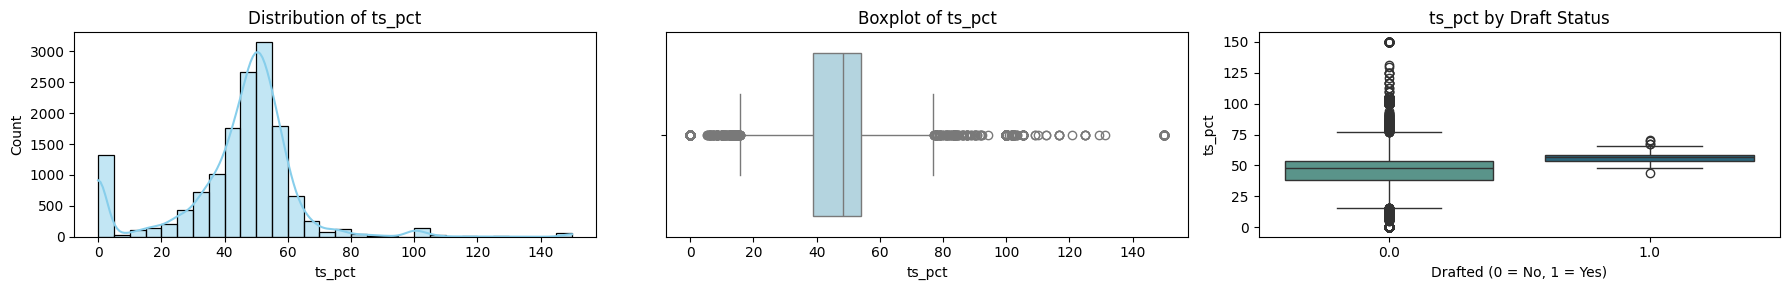

--- Visualizing: efg_pct ---


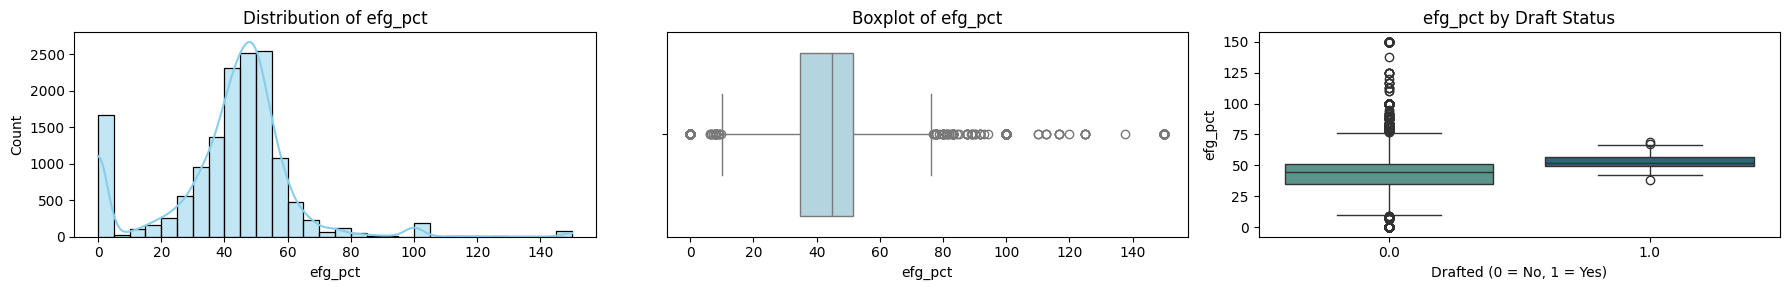

--- Visualizing: usage_pct ---


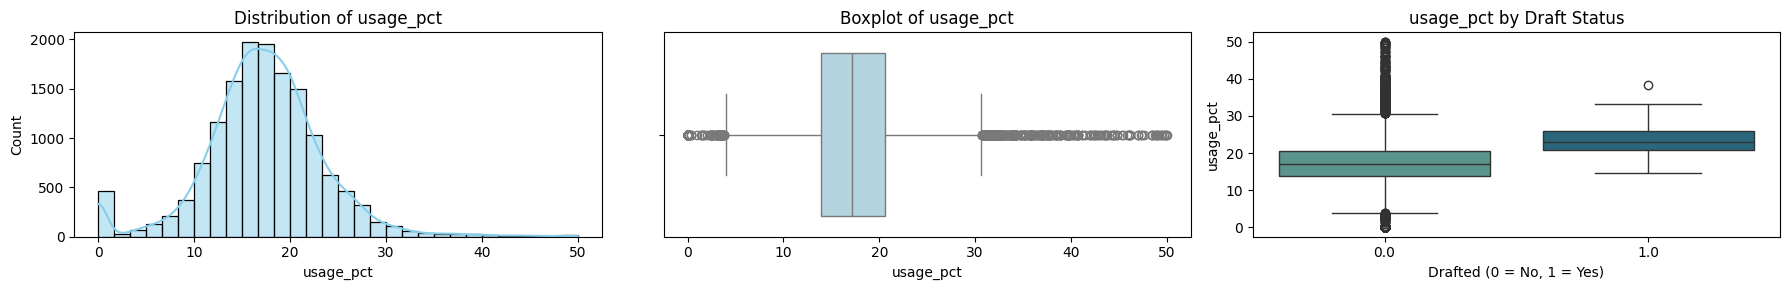

--- Visualizing: box_plus_minus ---


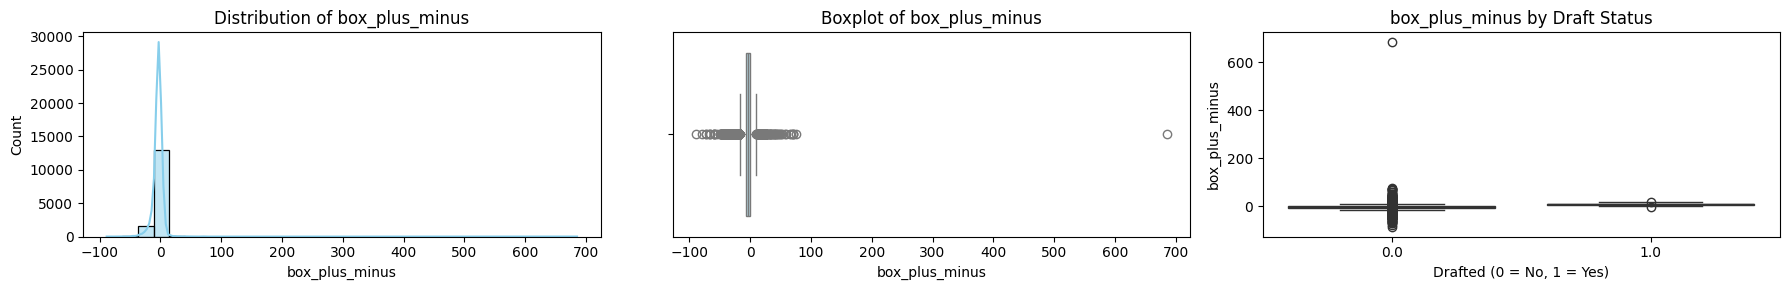

--- Visualizing: off_box_plus_minus ---


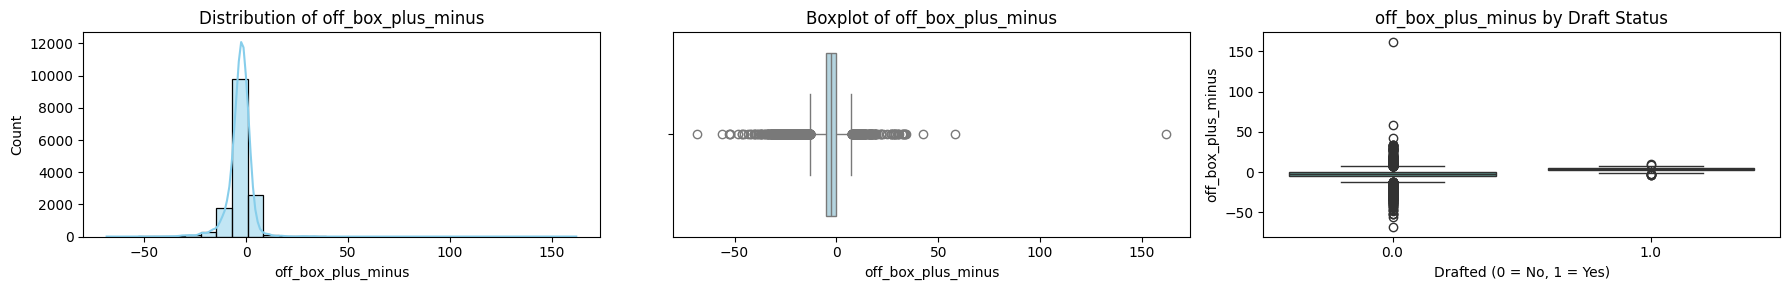

--- Visualizing: def_box_plus_minus ---


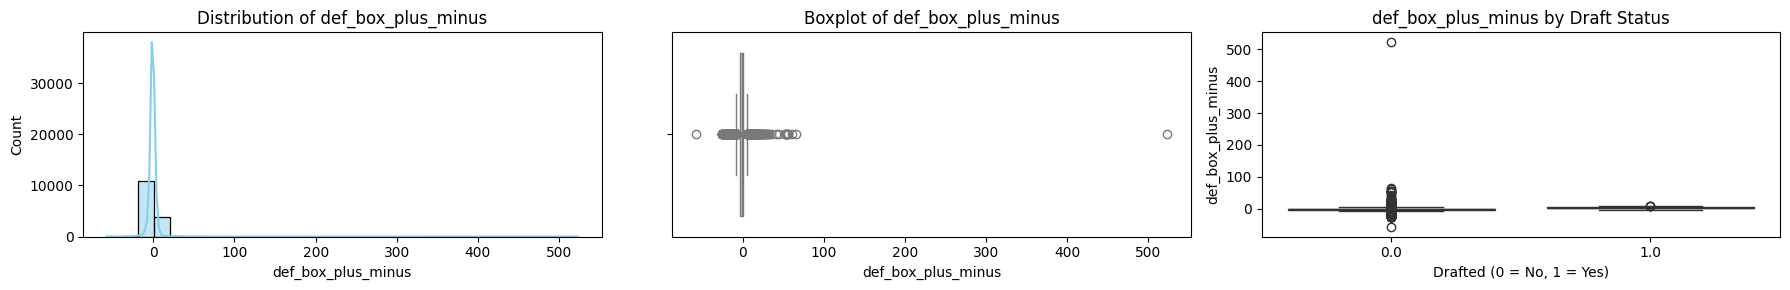

--- Visualizing: game_box_plus_minus ---


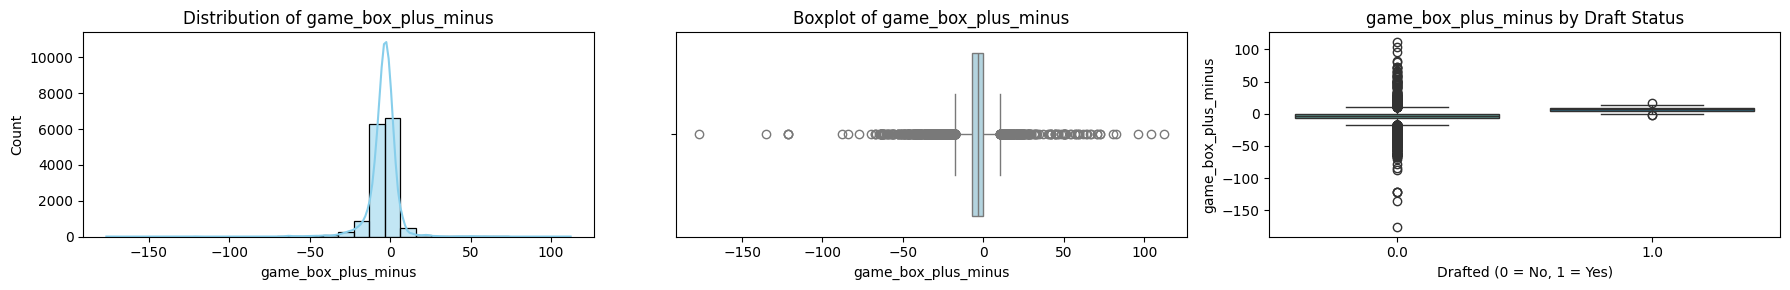

--- Visualizing: off_game_box_plus_minus ---


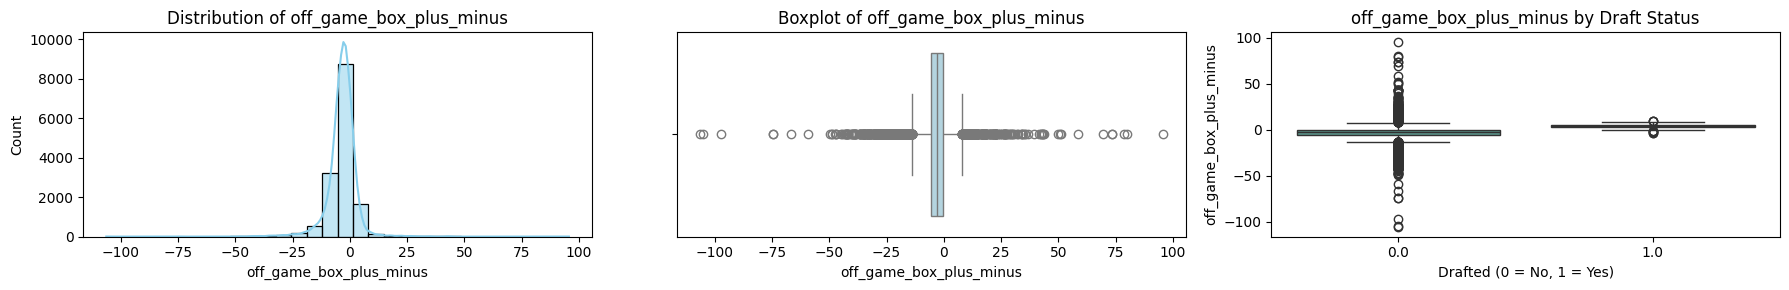

--- Visualizing: def_game_box_plus_minus ---


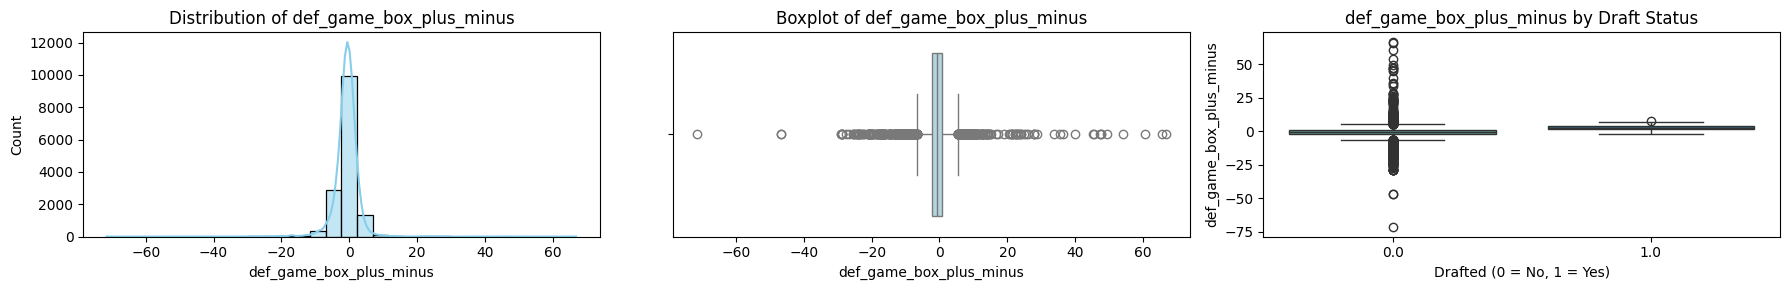

--- Visualizing: off_rating ---


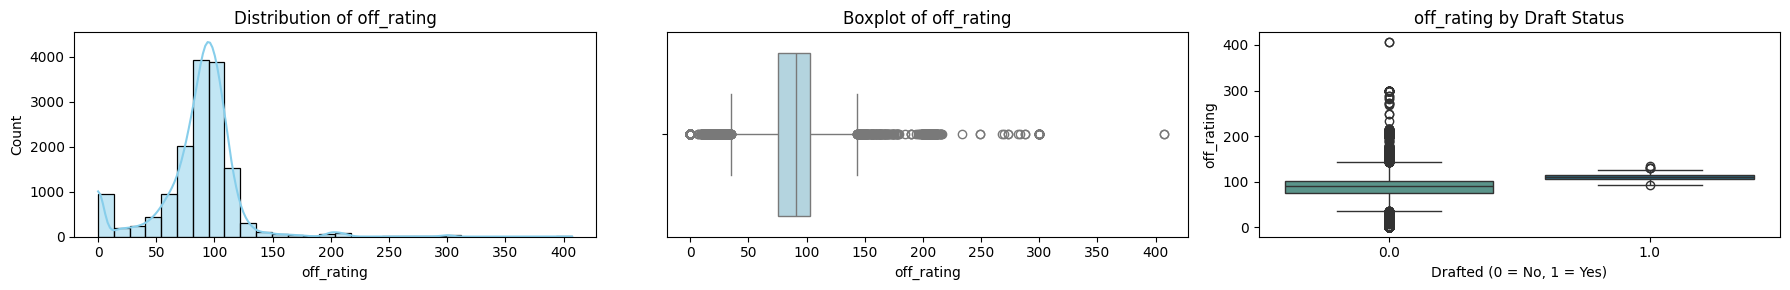

--- Visualizing: def_rating ---


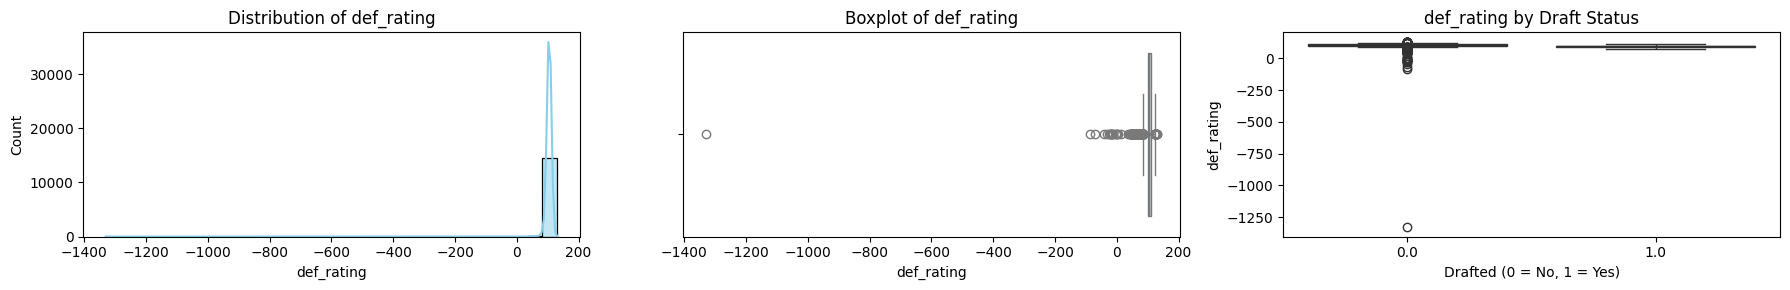

--- Visualizing: blk_pct ---


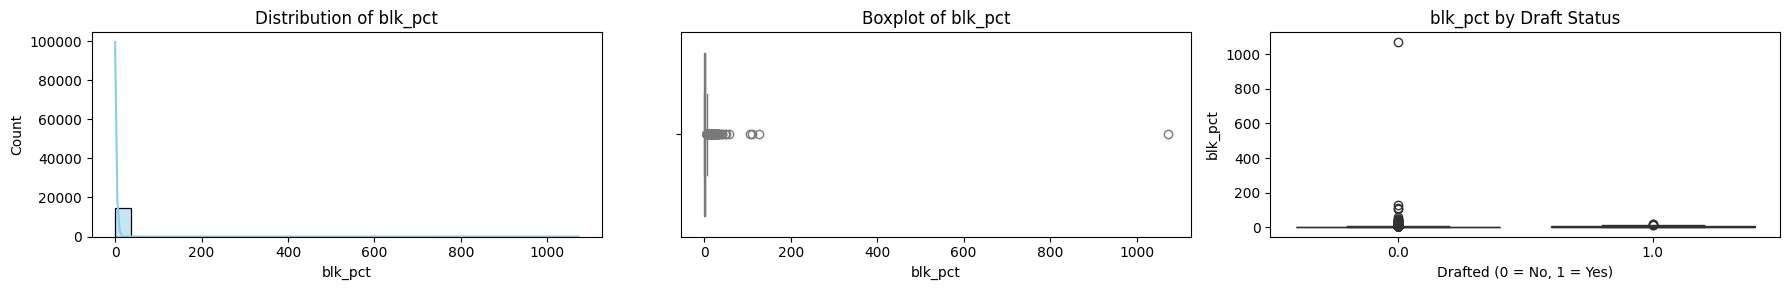

--- Visualizing: stl_pct ---


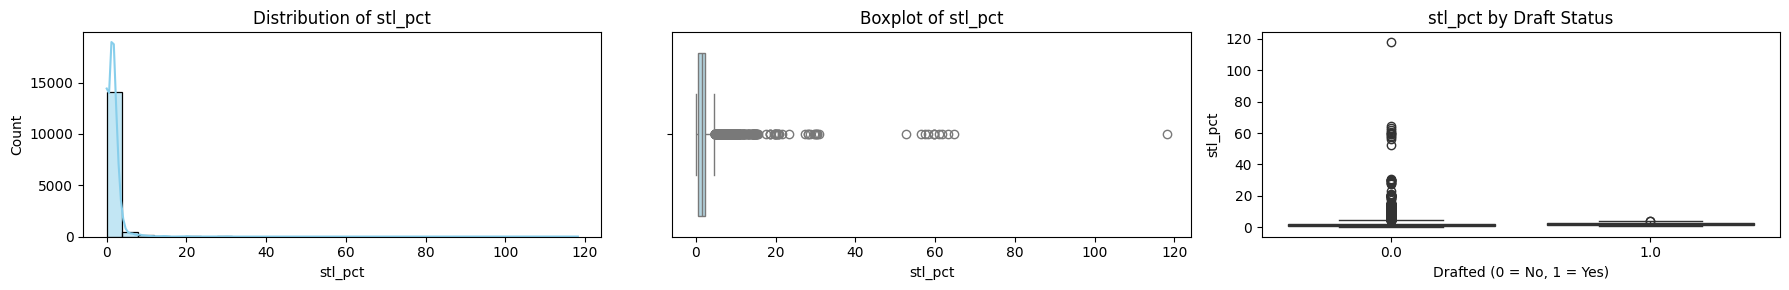

--- Visualizing: ast_pct ---


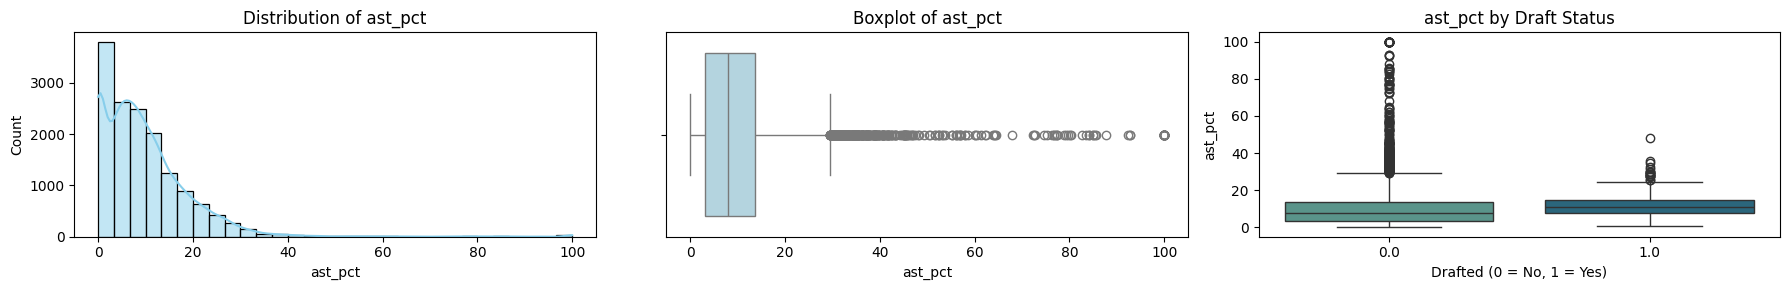

--- Visualizing: tov_pct ---


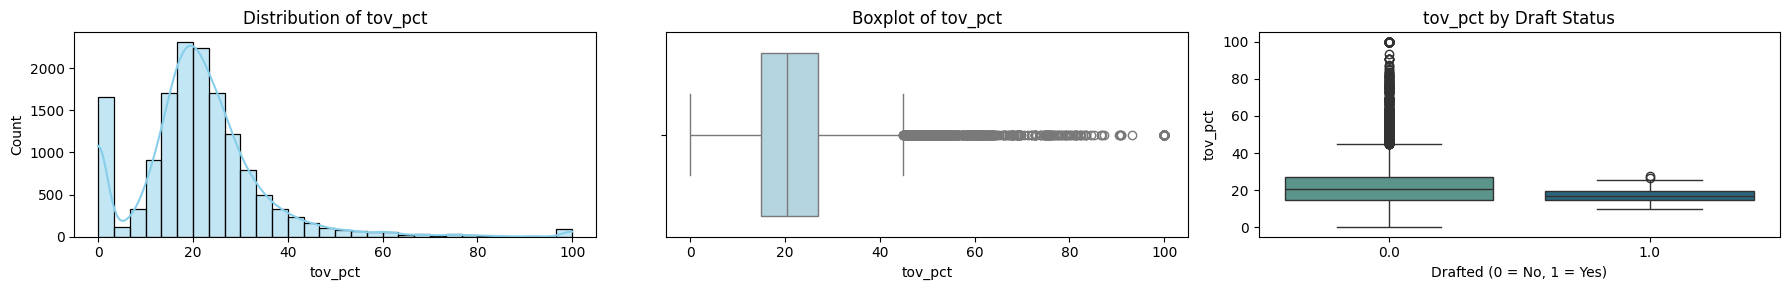

--- Visualizing: ast_tov_ratio ---


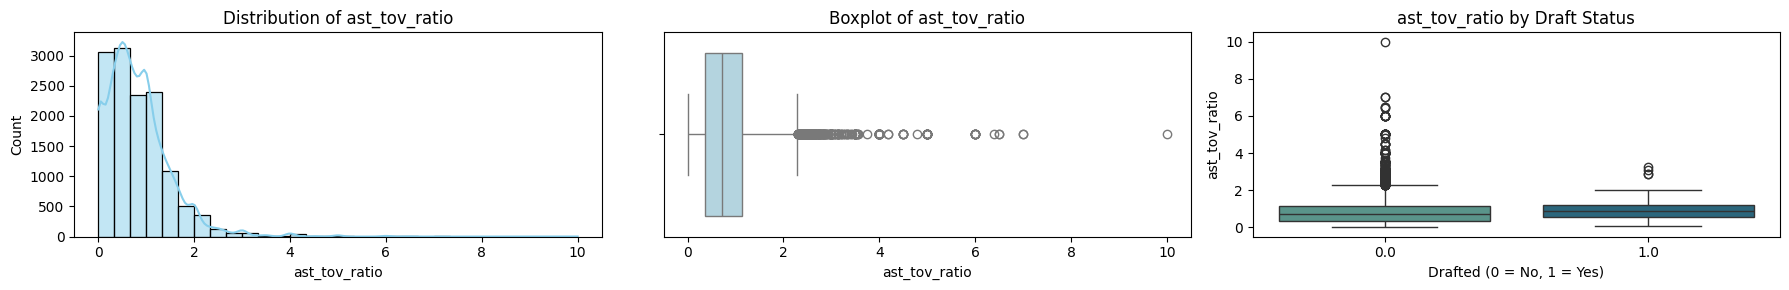

--- Visualizing: ft_pct ---


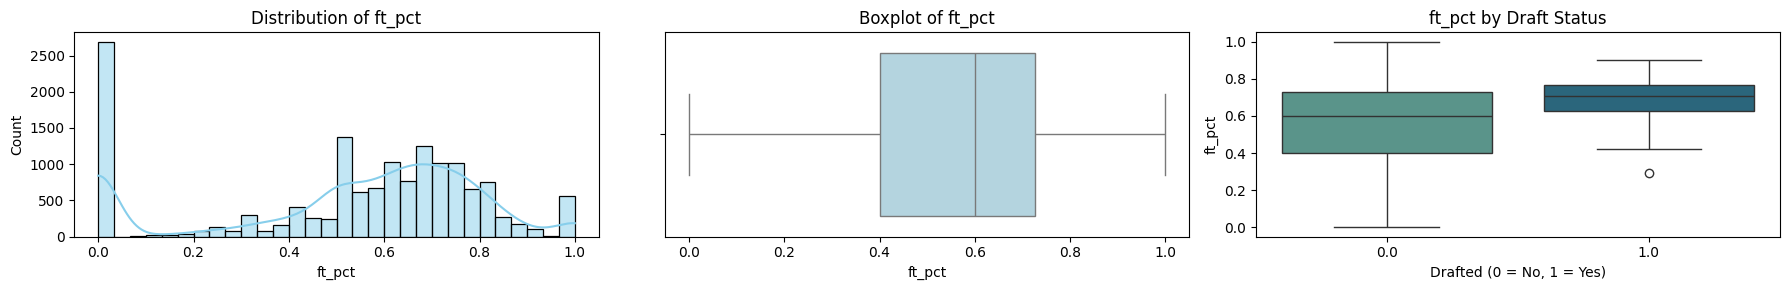

--- Visualizing: fg2m ---


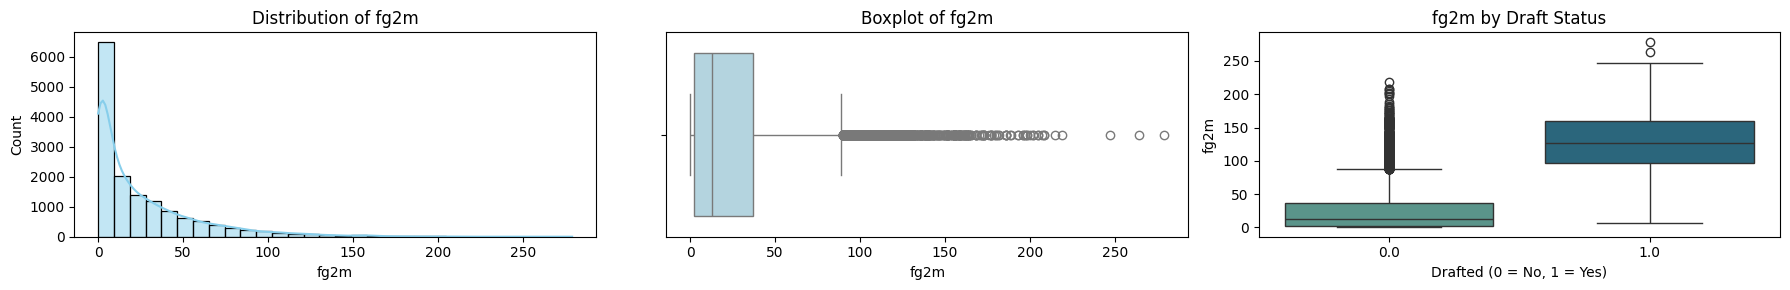

--- Visualizing: fg3_pct ---


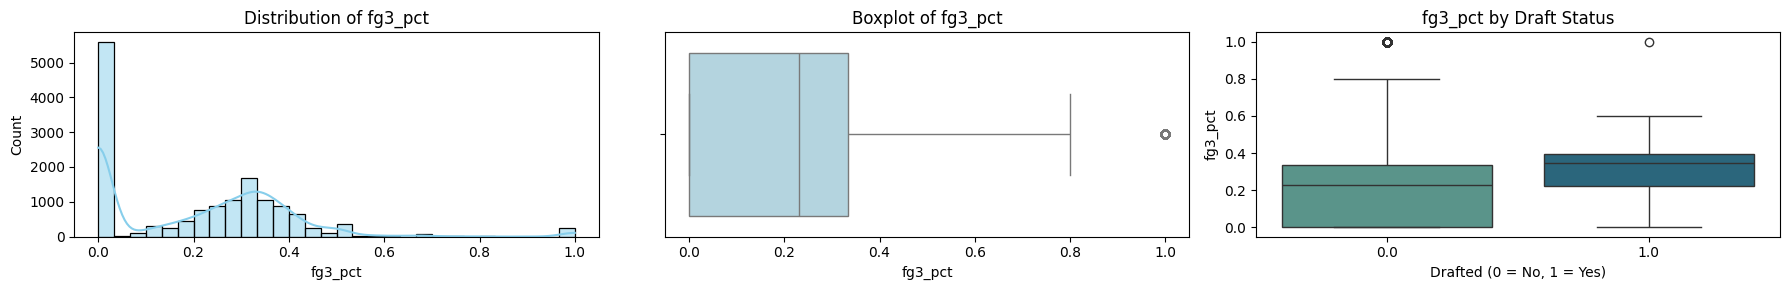

--- Visualizing: rim_shot_ratio ---


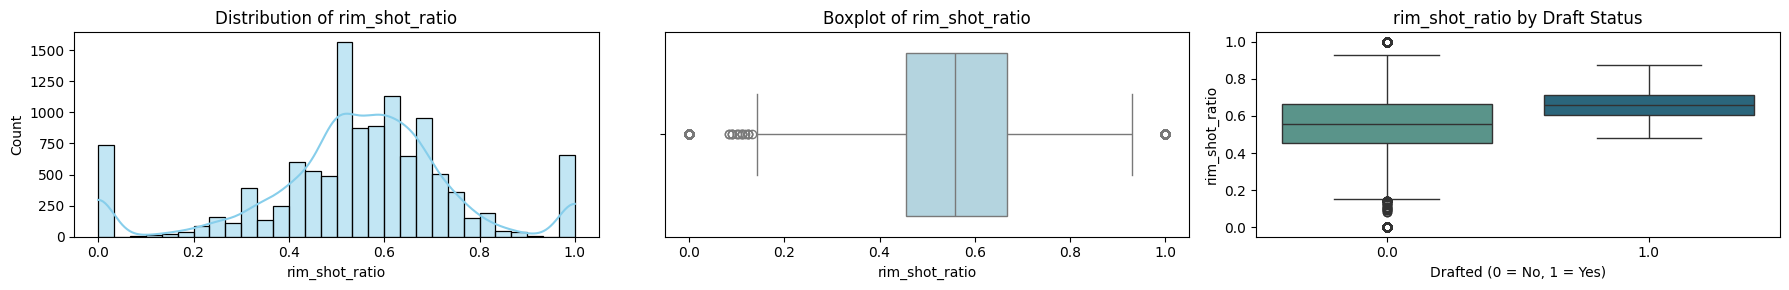

--- Visualizing: mid_shot_ratio ---


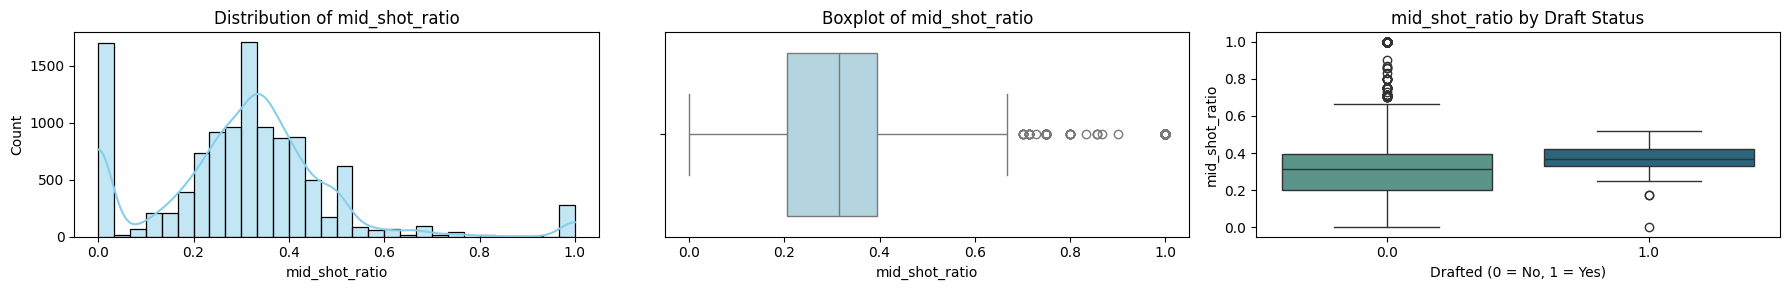

--- Visualizing: dunk_rate ---


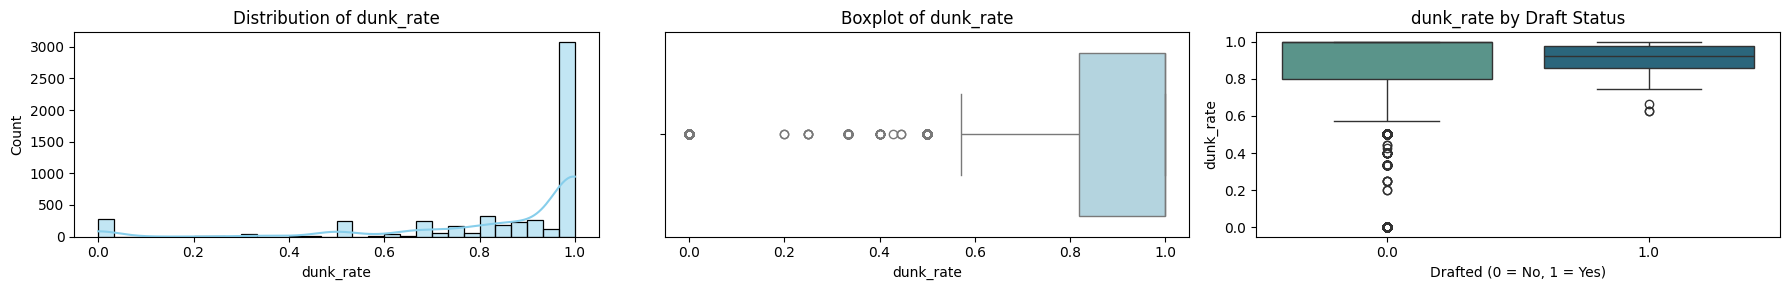

In [28]:
plotting_features = [
    'ts_pct', 'efg_pct', 'usage_pct', 'box_plus_minus', 'off_box_plus_minus', 'def_box_plus_minus', 'game_box_plus_minus', 'off_game_box_plus_minus', 'def_game_box_plus_minus',
    'off_rating', 'def_rating', 'blk_pct', 'stl_pct', 'ast_pct', 'tov_pct', 'ast_tov_ratio',
    'ft_pct', 'fg2m', 'fg3_pct', 'rim_shot_ratio', 'mid_shot_ratio', 'dunk_rate'
]

# Run plotting for visual features
for feature in plotting_features:
    plot_numerical_feature_distribution(train_df, feature)

**Numerical Features Analysis**

**Scope**
Comprehensive analysis of all numerical features across train (2009–2018) and test (2020) with attention to class separation between `drafted` and `undrafted`, distribution shape, missingness, drift, and modeling implications.

**Participation and volume**
- `minutes_played`, `min_pct`, `games_played`: `drafted` players log far greater time (median `minutes_played` ~29.35 vs ~10.15; `min_pct` ~69.8 vs ~19.4). Time on court is one of the strongest discriminators and should be included; consider capping extremes.
- `usage_pct`: clear right-shift for `drafted` (mean ~23.6 vs ~17.2), indicating larger offensive roles.

**Scoring and shooting splits**
- Counting stats `points`, `fg2m/fg2a`, `fg3m/fg3a` are all higher for `drafted`; medians often 3–5x those of `undrafted`.
- Efficiency `fg2_pct`, `fg3_pct`, `efg_pct`, `ts_pct` are modestly higher for `drafted` (e.g., `efg_pct` ~53.4 vs ~41.4; `ts_pct` ~56.6 vs ~44.5), reinforcing that it is not only volume but also conversion.
- `free_throw_rate` is higher for `drafted` (median ~43.8 vs ~31.6), consistent with star usage and rim pressure.

**Creation and ball security**
- `assists`, `ast_pct`, and `ast_tov_ratio` increase for `drafted`; `tov_pct` decreases (median ~16.8 vs ~20.5). Playmaking plus ball protection are additive signals beyond shooting.

**Rebounding**
- `offensive_rebounds`, `defensive_rebounds`, `total_rebounds` and percent counterparts `orb_pct`, `drb_pct` are higher among `drafted`, with especially strong separation in defensive glass. These features proxy size/athleticism and role.

**Defense and events**
- `steals`, `blocks` and rates `stl_pct`, `blk_pct` are higher for `drafted`. Paired with `def_rating`, `adj_def_rating`, `def_porpag`, and `def_stops`, drafted players show meaningfully better defensive impact (e.g., lower `def_rating` ~94.9 vs ~103.9; higher `def_stops` medians ~203 vs ~40).

**Shot profile and athleticism**
- Rim-centric metrics (`rim_fg_made/att`, `rim_shot_ratio`) and `dunk_rate` are substantially higher for `drafted` (e.g., `dunk_rate` mean ~0.91 vs ~0.86 where available), suggesting NBA-caliber athleticism and shot quality at the rim.
- Midrange usage (`mid_shot_ratio`) skews slightly higher for `drafted`, but lift is smaller than at-rim indicators.

**Advanced efficiency and impact**
- `off_rating` and `adj_off_eff` are much better for `drafted` (means ~110 and ~121 vs ~86 and ~82), while `def_rating` and `adj_def_rating` are lower (better).
- BPM family (`box_plus_minus`, `off_box_plus_minus`, `def_box_plus_minus`, and their game variants) shows the largest signal shift: `drafted` BPM ~6.6 vs ~-4.2 overall. These aggregate diverse box stats into a single high-signal feature group.

**Prospect quality and discipline**
- `recruit_rank` is extremely informative where present (mean ~97 for `drafted` vs ~53 for `undrafted`), but is missing for many rows; retain with a missingness flag.
- `personal_foul_rate` is slightly lower for `drafted` (median ~3.20 vs ~4.10), hinting at better discipline or defensive positioning, but effect size is modest.

**Distribution shape and outliers**
- Many percent-like metrics (`min_pct`, `usage_pct`, `efg_pct`, `ts_pct`, `orb_pct`, `drb_pct`, `blk_pct`, `stl_pct`, `tov_pct`, `ast_pct`, `free_throw_rate`) are recorded on a 0–100 scale; rescale to 0–1 for linear models and apply winsorization. Some extreme maxima (e.g., `orb_pct` > 1000, `drb_pct` > 1000, negative `def_rating`) are clearly noisy and should be clipped to percentile thresholds.
- Counts are long-tailed (e.g., `fta`, `fg2a`, `fg3a`, `rim_*`, `mid_*`, `dunks_*`); use robust scalers for linear models or leave raw for trees.

**Missingness**
- Partial coverage in `recruit_rank`, `rim_*`, `mid_*`, and `dunks_*`, and especially `dunk_rate`. Strategy: median impute numeric + add binary missing flags for high-value features (`recruit_rank`, `dunk_rate`, shot profile splits).

**Temporal drift**
- `season_year` differs (train 2009–2018 vs test 2020). Keep `season_year` to absorb era effects and prefer time-aware validation; avoid any target leakage.

**Feature interactions to consider**
- Efficiency-at-volume: `usage_pct * ts_pct`, `usage_pct * efg_pct`, and `min_pct * ts_pct`.
- Finishing profile: `rim_shot_ratio * efg_pct`, `dunk_rate * off_rating`.
- Two-way impact: `box_plus_minus` with `def_rating` and `ast_tov_ratio`.
- Role separation: combine `minutes_played`, `usage_pct`, and `ast_pct` to distinguish primary creators vs finishers.

**Modeling implications**
- Highest expected signal: BPM family, offensive/defensive ratings, `usage_pct`, `min_pct`, rim/dunk profile, `recruit_rank` (with flag), `ts_pct/efg_pct`.
- Stabilizers: per-100 or per-possession style metrics (ratings/BPM) reduce noise from raw counts.
- Preprocessing: rescale 0–100 metrics to 0–1, winsorize advanced ratings and noisy rates, impute + flag missing.

In [29]:
# <Student to fill this section>
feature_1_insights = """
Drafted players are consistently higher in volume, efficiency, creation, defense, rim/dunk profile, BPM, and recruit rank, so keep and clean those signals (rescale, winsorize, impute+flag) and consider interactions like usage_pct*ts_pct for best AUROC.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest - `categorical features`

In [31]:
# <Student to fill this section>

In [32]:
def summarize_categorical_feature(df, cat_feature, target='drafted',
                                  include_missing=True, missing_label='<MISSING>',
                                  sort_by='Draft Rate (%)', ascending=False):
    """
    Summarize counts, drafted/undrafted, draft rate, and share for a categorical feature (or list of features).
    NaNs are kept as a '<MISSING>' level if include_missing=True.
    """
    # normalize to list
    cats = [cat_feature] if isinstance(cat_feature, str) else list(cat_feature)

    s = df[cats + [target]].copy()
    # keep missing as a category
    if include_missing:
        for c in cats:
            s[c] = s[c].astype('object').where(~s[c].isna(), missing_label)

    # drop NaNs in target if any
    s = s[~s[target].isna()]

    summary = (
        s.groupby(cats)[target]
         .agg(['count', 'sum'])
         .rename(columns={'count': 'Total', 'sum': 'Drafted'})
         .reset_index()
    )
    summary['Undrafted'] = summary['Total'] - summary['Drafted']
    summary['Draft Rate (%)'] = (summary['Drafted'] / summary['Total'] * 100).round(2)
    summary['Share (%)'] = (summary['Total'] / len(df) * 100).round(2)

    return summary.sort_values(by=sort_by, ascending=ascending)

In [33]:
# Categorical features from object and bool types
categorical_features = train_df.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Categorical features lists: ", categorical_features)

for cat_feature in categorical_features:
    print(f"Draft Summary by {cat_feature.upper()} (`{cat_feature}`):")
    display(summarize_categorical_feature(train_df, cat_feature))

Categorical features lists:  ['player_id', 'team', 'conference', 'height', 'class_year', 'dataset_type']
Draft Summary by PLAYER_ID (`player_id`):


,player_id,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
2234,2f84131f-8e46-437b-a19f-75d98c8355ef,1,1.0,0.0,100.0,0.01
3334,460acfb3-fdc3-49a6-a2fd-6c7e4ae661cf,1,1.0,0.0,100.0,0.01
831,1137a88e-af51-4312-9673-4941e6f749f0,1,1.0,0.0,100.0,0.01
5593,75746512-7b26-406f-b8d3-c65c6a61c7a2,1,1.0,0.0,100.0,0.01
3034,3fc7419d-2bd1-4185-819f-7e21a5f49ee5,1,1.0,0.0,100.0,0.01
...,...,...,...,...,...,...
12134,ff8aa5e3-9132-4ed4-9f37-14758c0bd372,1,0.0,1.0,0.0,0.01
12135,ff940618-59b3-49ee-8c59-3296089dc89c,1,0.0,1.0,0.0,0.01
12136,ff972993-436d-4e29-87c9-49d50c6997f2,1,0.0,1.0,0.0,0.01
12137,ff9afd91-0e5c-45f6-827e-58a6b9fa2a8a,1,0.0,1.0,0.0,0.01


Draft Summary by TEAM (`team`):


,team,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
138,Kentucky,67,28.0,39.0,41.79,0.45
73,Duke,52,13.0,39.0,25.00,0.35
134,Kansas,54,7.0,47.0,12.96,0.37
10,Arizona,58,7.0,51.0,12.07,0.39
291,Texas,50,6.0,44.0,12.00,0.34
...,...,...,...,...,...,...
326,VCU,43,0.0,43.0,0.00,0.29
325,Utah Valley,22,0.0,22.0,0.00,0.15
324,Utah St.,42,0.0,42.0,0.00,0.28
323,Utah,44,0.0,44.0,0.00,0.30


Draft Summary by CONFERENCE (`conference`):


...

,height,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
31,Jul-00,167,8.0,159.0,4.79,1.13
7,11-Jun,279,13.0,266.0,4.66,1.89
5,10-Jun,626,19.0,607.0,3.04,4.24
2,1-Jul,48,1.0,47.0,2.08,0.32
21,6-Jun,1321,16.0,1305.0,1.21,8.94
27,9-Jun,1013,11.0,1002.0,1.09,6.86
25,8-Jun,1440,12.0,1428.0,0.83,9.75
13,3-Jun,1413,10.0,1403.0,0.71,9.56
18,5-Jun,1390,9.0,1381.0,0.65,9.41
10,2-Jun,1264,6.0,1258.0,0.47,8.56


Draft Summary by CLASS_YEAR (`class_year`):


,class_year,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
0,Fr,14774,118.0,14656.0,0.8,100.0


Draft Summary by DATASET_TYPE (`dataset_type`):


,dataset_type,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
0,all,14774,118.0,14656.0,0.8,100.0


**Categorical Features Analysis**  

**Scope**
Assessment of categorical features `player_id`, `team`, `conference`, `height`, `class_year`, `dataset_type` using draft-rate tables and known data quirks to decide modeling roles, encodings, and safeguards.

**player_id**
- Nature: unique identifier; appears many-to-one with rows and occasionally repeats across seasons.
- Signal vs leakage: very high leakage risk if used directly; encodes the label for any seen `player_id`.
- Role: keep only for de-duplication, grouping, joins, and error analysis; EXCLUDE from features.
- Actions: use `player_id` to detect duplicates across `season_year`, to aggregate per-player diagnostics, and to map false positives/negatives after scoring.

**team**
- Cardinality: very high (355 teams), heavy imbalance (e.g., Kentucky `draft_rate` ~41.79%, Duke ~25.00%, many teams at 0%).
- Pros: team captures recruiting/coaching/program strength; predictive.
- Cons: high risk of overfit; unseen categories in 2020 need robust handling.
- Drift: team names can vary; enforce a canonical mapping before encoding; maintain an "unseen" bucket for novel teams.

**conference**
- Cardinality: moderate; some power leagues show higher `draft_rate` (SEC ~5.27%, P12 ~4.55%, ACC ~3.37) while many conferences have 0%.
- Encoding plan: one-hot is feasible; or light target encoding with strong smoothing.
- Notes: conference can proxy schedule strength; keep even if `team` is encoded, as it adds coarse-grained signal with lower overfit risk.

**height**
- Quality: messy categorical strings (e.g., `11-Jun`, `Jul-00`, `6-Jun`, `-`, `MISSING`) likely mis-parsed from formats like `6-6` or `7-0`.
- Rationale: numeric inches avoids sparse encodings and fixes inconsistent tokens; height has plausible relationship with `blk_pct`, `rebounds`, and `rim`/`dunk` metrics.

**class_year**
- Distribution: single value `Fr` across dataset (100%).
- Action: drop from features (no variance), but document that dataset focuses on freshmen; no class-seniority signal available.

**dataset_type**
- Distribution: single value `all`.
- Action: drop from features (no variance).

**Encoding and CV safeguards**
- For any target encoding (`team`, optional `conference`):
  - Use K-fold out-of-fold means with additive smoothing toward the global prior `P(drafted)`, plus small Gaussian noise during training.
  - Refit encoders on full train after CV; during inference, map unseen to prior.
- For one-hot:
  - Use `OneHotEncoder(handle_unknown="ignore")` so unseen categories do not error.
- Keep a reproducible category map versioned with the code to ensure train/test parity.

**Operational checks**
- Canonicalize names before encoding (e.g., `UNC Wilmington` vs `North Carolina-Wilmington`).
- Log the top categories by frequency and by `draft_rate` to monitor drift into 2020.
- Export an errors table keyed by `player_id` + `season_year` to review misclassifications and potential data issues.

**Decision**
- Features to DROP: `player_id` (as feature), `class_year`, `dataset_type`.
- Features to KEEP/ENCODE: `team` (target encoding with smoothing), `conference` (one-hot or smoothed target encoding), `height` (convert to inches + missing flag; optionally bucket).

In [34]:
# <Student to fill this section>
feature_2_insights = """
Use target encoding for team, one-hot for conference, and convert height to numeric inches with a missing flag; drop player_id, class_year, and dataset_type from features to avoid leakage and non-informative variance.
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

---
## D. Feature Selection


### D.1 Drop explicit single-valued columns


In [36]:
# <Student to fill this section>

In [37]:
# Drop explicit single-valued columns from training and test datasets
cols_to_drop = ['class_year', 'dataset_type']
train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

print("Columns after dropping single-valued columns:")
print(train_df.info())

Columns after dropping single-valued columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   player_id                14774 non-null  object 
 1   team                     14774 non-null  object 
 2   conference               14774 non-null  object 
 3   season_year              14774 non-null  int64  
 4   height                   14766 non-null  object 
 5   recruit_rank             4889 non-null   float64
 6   games_played             14774 non-null  int64  
 7   min_pct                  14774 non-null  float64
 8   minutes_played           14773 non-null  float64
 9   fta                      14774 non-null  int64  
 10  ftm                      14774 non-null  int64  
 11  ft_pct                   14774 non-null  float64
 12  free_throw_rate          14774 non-null  float64
 13  fg2a                     14774

**Feature Selection — Constant Feature Removal**

- Reduced the number of model features by removing `class_year` and `dataset_type`.  
- No expected impact on AUROC other than a small improvement in stability and training time due to fewer useless features.  
- Eliminated potential zero-variance warnings in preprocessing pipelines.

In [38]:
# <Student to fill this section>
feature_selection_1_insights = """
Constant-feature removal: we dropped single-valued class_year and dataset_type from the model features to reduce noise and zero-variance issues, improving training stability while keeping player_id only as a key (not a feature).
"""

In [39]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach - Redundancy & Multicollinearity

In [40]:
# <Student to fill this section>

In [41]:
def _preference_score(col: str) -> int:
    """
    Prefer rates/percentages/ratings over raw counts when features are highly correlated.
    Tune the keywords to your schema.
    """
    col_lower = col.lower()
    score = 0
    if any(k in col_lower for k in ["_pct", "_rate", "ratio", "rating", "eff", "porpag", "box_plus_minus"]):
        score += 3
    if any(k in col_lower for k in ["share", "shot_ratio"]):
        score += 2
    if any(k in col_lower for k in ["made", "_m", "_att", "_a", "points", "assists", "rebounds"]):
        score += 0
    return score


def _select_numeric(df: pd.DataFrame, cols: List[str]) -> Tuple[pd.DataFrame, List[str]]:
    X = df[cols].copy()
    nunique = X.nunique(dropna=True)
    const_cols = nunique[nunique <= 1].index.tolist()
    if const_cols:
        X = X.drop(columns=const_cols)
    return X, const_cols


def _prune_by_correlation(
    X: pd.DataFrame,
    y: Optional[pd.Series] = None,
    threshold: float = 0.92
) -> Tuple[List[str], List[Tuple[str, str, Tuple[str, str], float]]]:
    """
    Remove one feature from any pair with abs Spearman correlation >= threshold.
    Tie-breakers (in order): preference score, lower missingness, higher |corr with y|, higher variance.
    """
    cols = list(X.columns)
    dropped = []

    while True:
        corr = X[cols].corr(method="spearman").abs()
        np.fill_diagonal(corr.values, 0.0)
        max_val = corr.values.max()
        if max_val < threshold or len(cols) <= 2:
            break

        i, j = np.unravel_index(np.argmax(corr.values), corr.shape)
        c1, c2 = cols[i], cols[j]

        miss1, miss2 = X[c1].isna().mean(), X[c2].isna().mean()
        var1, var2   = X[c1].var(skipna=True), X[c2].var(skipna=True)
        pref1, pref2 = _preference_score(c1), _preference_score(c2)

        if y is not None:
            # point-biserial via Pearson with binary/continuous y
            ycorr1 = abs(pd.Series(X[c1]).corr(y))
            ycorr2 = abs(pd.Series(X[c2]).corr(y))
        else:
            ycorr1 = ycorr2 = 0.0

        rank1 = (pref1, -miss1, ycorr1, var1)
        rank2 = (pref2, -miss2, ycorr2, var2)

        # Keep the higher-ranked; drop the other
        drop = c2 if rank1 >= rank2 else c1
        cols.remove(drop)
        dropped.append((drop, f"corr>={threshold:.2f}", (c1, c2), float(max_val)))

    return cols, dropped

# VIF without statsmodels

def _compute_vif_from_corr(Z: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """
    Compute VIFs from standardized design matrix Z (n x p).
    VIF_j = diagonal of inverse of correlation matrix R = (Z^T Z)/(n-1).
    A small ridge (eps) is added to the diagonal for numerical stability.
    """
    n = Z.shape[0]
    if n <= 1:
        return np.ones(Z.shape[1], dtype=float)

    # Correlation matrix of standardized columns equals (Z^T Z) / (n-1)
    R = (Z.T @ Z) / max(n - 1, 1)

    # Regularize to avoid singularities
    R_reg = R + eps * np.eye(R.shape[0], dtype=R.dtype)

    # Use pseudo-inverse for robustness
    R_inv = np.linalg.pinv(R_reg)
    vifs = np.diag(R_inv)
    # Guard against tiny negatives from numeric noise
    vifs = np.maximum(vifs, 1.0)
    return vifs


def _prune_by_vif(
    X: pd.DataFrame,
    cols: List[str],
    vif_threshold: float = 8.0
) -> Tuple[List[str], List[Tuple[str, float]], pd.Series]:
    """
    Iteratively drop the column with the highest VIF until all VIF <= vif_threshold.
    Median imputation and standardization are used for numerical stability.
    Implementation is self-contained (no statsmodels).
    """
    dropped: List[Tuple[str, float]] = []

    imp = SimpleImputer(strategy="median")
    Z = imp.fit_transform(X[cols].astype(float))

    scaler = StandardScaler()
    Z = scaler.fit_transform(Z)

    while True:
        vifs_arr = _compute_vif_from_corr(Z)  # shape (p,)
        vifs = pd.Series(vifs_arr, index=cols)

        max_vif = float(vifs.max())
        if max_vif <= vif_threshold or len(cols) <= 2:
            final_vifs = vifs.sort_values(ascending=False)
            break

        drop_col = str(vifs.idxmax())
        dropped.append((drop_col, max_vif))

        # remove from arrays and list
        idx = cols.index(drop_col)
        cols.pop(idx)
        Z = np.delete(Z, idx, axis=1)

    return cols, dropped, final_vifs

# Public pipeline

def prune_redundancy(
    df: pd.DataFrame,
    numeric_cols: List[str],
    y: Optional[pd.Series] = None,
    corr_threshold: float = 0.92,
    vif_threshold: float = 8.0
) -> Dict:
    """
    Full pipeline: drop constants -> correlation pruning -> VIF pruning (no statsmodels).
    """
    X, const_cols = _select_numeric(df, numeric_cols)
    kept_corr, dropped_corr = _prune_by_correlation(X, y=y, threshold=corr_threshold)
    kept_vif, dropped_vif, final_vif = _prune_by_vif(X, kept_corr, vif_threshold=vif_threshold)

    return dict(
        kept_features=kept_vif,
        dropped_constants=const_cols,
        dropped_by_correlation=dropped_corr,
        dropped_by_vif=dropped_vif,
        final_vif=final_vif.to_dict()
    )

In [42]:
y_prune = train_df["drafted"].astype(int)

In [43]:
result = prune_redundancy(train_df, numerical_features, y=y_prune, corr_threshold=0.92, vif_threshold=8.0)

In [44]:
print(f"Kept {len(result['kept_features'])} features")
print(f"Final kept features: {result['kept_features']}")
print(f"Dropped constants: {result['dropped_constants']}")
print(f"Dropped by correlation: {result['dropped_by_correlation']}")
print(f"Dropped by VIF: {result['dropped_by_vif']}")
print(f"Final VIF: {result['final_vif']}")

Kept 30 features
Final kept features: ['season_year', 'recruit_rank', 'games_played', 'ft_pct', 'free_throw_rate', 'fg2_pct', 'fg3m', 'fg3_pct', 'ts_pct', 'rim_shot_ratio', 'mid_fg_made', 'mid_shot_ratio', 'dunks_made', 'dunk_rate', 'usage_pct', 'porpag', 'personal_foul_rate', 'ast_tov_ratio', 'off_box_plus_minus', 'def_box_plus_minus', 'off_game_box_plus_minus', 'def_game_box_plus_minus', 'assists', 'steals', 'offensive_rebounds', 'defensive_rebounds', 'drb_pct', 'ast_pct', 'tov_pct', 'stl_pct']
Dropped constants: []
Dropped by correlation: [('def_stops', 'corr>=0.92', ('min_pct', 'def_stops'), 0.9866240399991274), ('ftm', 'corr>=0.92', ('fta', 'ftm'), 0.9861692001774194), ('fg2a', 'corr>=0.92', ('fg2a', 'fg2m'), 0.9855428350243712), ('rim_fg_att', 'corr>=0.92', ('rim_fg_made', 'rim_fg_att'), 0.9834207659823032), ('dunks_att', 'corr>=0.92', ('dunks_made', 'dunks_att'), 0.977600642155901), ('total_rebounds', 'corr>=0.92', ('defensive_rebounds', 'total_rebounds'), 0.9759269512414696), (

**Feature Selection: Redundancy & Multicollinearity**

**Why**

Reduce noise and instability caused by redundant predictors and multicollinearity so that models generalize better, coefficients are stable (for linear/logistic), and feature importances are interpretable.

**Method**
- **Constant/near-constant check:** drop features with zero variance. Result: none dropped.
- **Pairwise correlation pruning:** compute absolute Spearman correlations on the training set and iteratively drop one feature from any pair with `|rho| >= 0.92`. Tie-break rule: keep the more interpretable, rate-like, or coverage-rich variable; drop the count/exposure or composite when appropriate.
- **VIF pruning:** compute VIF on the remaining set and iteratively remove the feature with the largest `VIF > 8.0` until all remaining features satisfy the threshold.

**Key drops by correlation (examples)**
- Exposure/duplicate pairs: (`min_pct`, `minutes_played`), (`fg2m`, `fg2a`), (`rim_fg_made`, `rim_fg_att`), (`dunks_made`, `dunks_att`), (`fg3m`, `fg3a`), (`defensive_rebounds`, `total_rebounds`).
- Metric duplicates: (`off_rating`, `adj_off_eff`), (`efg_pct`, `ts_pct`).
- Count vs attempt/FTA: (`fta`, `ftm`).
- Blocks level vs rate: (`blocks`, `blk_pct`).

**Key drops by VIF**
- Composite box metrics: `game_box_plus_minus`, then `box_plus_minus`.
- Ratings with strong linear ties: `def_rating`, `adj_def_rating`.
- Heavy exposure proxies: `min_pct`, `points`.
- Additional collinear metrics: `blk_pct`, `orb_pct`, `def_porpag`, `adj_off_eff`.

**Final kept feature set (30)**
`season_year`, `recruit_rank`, `games_played`, `ft_pct`, `free_throw_rate`, `fg2_pct`, `fg3m`, `fg3_pct`, `ts_pct`, `rim_shot_ratio`, `mid_fg_made`, `mid_shot_ratio`, `dunks_made`, `dunk_rate`, `usage_pct`, `porpag`, `personal_foul_rate`, `ast_tov_ratio`, `off_box_plus_minus`, `def_box_plus_minus`, `off_game_box_plus_minus`, `def_game_box_plus_minus`, `assists`, `steals`, `offensive_rebounds`, `defensive_rebounds`, `drb_pct`, `ast_pct`, `tov_pct`, `stl_pct`.

**Diagnostics**
- Final VIF range: 1.05 to 7.13 (all <= 8.0).
- Multicollinearity materially reduced while retaining diverse skill, shooting, efficiency, defensive and contextual signals.

**Impact**
- Lower risk of overfitting and coefficient blow-up.
- Clearer, non-duplicated signals for tree ensembles and linear baselines.
- Simpler downstream feature engineering and easier error analysis.

**Notes**
- Counts vs rates: we kept a balanced mix; optional variants include a rate-first set (drop counts) or re-introducing exposure (e.g., `minutes_played`) if modeling counts explicitly.
- `recruit_rank` has missingness; handle with fold-safe imputation and a missingness flag during modeling.

In [45]:
# <Student to fill this section>
feature_selection_2_insights = """
Reduce redundant and collinear predictors via correlation (>=0.92) and VIF (>8) pruning, yielding 30 stable, non-duplicative features with final VIFs <= 7.13 for better generalization and interpretability.
"""

In [46]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.z Final Selection of Features

In [47]:
# Get the list of features kept after pruning (these are the numerical features)
kept_numerical_features = result['kept_features']

# Define the categorical features to keep
kept_categorical_features = ['player_id', 'team', 'conference', 'height']

# Get the initial preferred order
initial_preferred_order = [
    # Identifiers (excluding player_id, class_year, dataset_type, which are not features)
    'player_id', 'team', 'team_draft_segment', 'conference', 'season_year', 'height', 'height_in_cm', 'recruit_rank',

    # Game participation
    'games_played', 'min_pct', 'minutes_played',

    # Free throws
    'fta', 'ftm', 'ft_pct', 'free_throw_rate',

    # 2-point field goals
    'fg2a', 'fg2m', 'fg2_pct',

    # 3-point field goals
    'fg3a', 'fg3m', 'fg3_pct',

    # Shooting efficiency
    'efg_pct', 'ts_pct',

    # Shot zones
    'rim_fg_made', 'rim_fg_att', 'rim_shot_ratio',
    'mid_fg_made', 'mid_fg_att', 'mid_shot_ratio',
    'dunks_made', 'dunks_att', 'dunk_rate',

    # Usage and offensive/defensive efficiency
    'usage_pct', 'off_rating', 'adj_off_eff', 'porpag', 'def_porpag', 'personal_foul_rate', 'ast_tov_ratio',

    # Defensive metrics
    'def_rating', 'adj_def_rating', 'def_stops',

    # BPM metrics
    'box_plus_minus', 'off_box_plus_minus', 'def_box_plus_minus', 'game_box_plus_minus', 'off_game_box_plus_minus', 'def_game_box_plus_minus',

    # Box stats
    'points', 'assists', 'steals', 'blocks', 'offensive_rebounds', 'defensive_rebounds', 'total_rebounds',

    # Percentages
    'orb_pct', 'drb_pct', 'ast_pct', 'tov_pct', 'blk_pct', 'stl_pct',
]

# Combine the kept numerical and categorical features
all_kept_features = kept_numerical_features + kept_categorical_features

# Create the final features_list in the preferred order
features_list = [col for col in initial_preferred_order if col in all_kept_features]

print("Final features list:")
print(features_list)

Final features list:
['player_id', 'team', 'conference', 'season_year', 'height', 'recruit_rank', 'games_played', 'ft_pct', 'free_throw_rate', 'fg2_pct', 'fg3m', 'fg3_pct', 'ts_pct', 'rim_shot_ratio', 'mid_fg_made', 'mid_shot_ratio', 'dunks_made', 'dunk_rate', 'usage_pct', 'porpag', 'personal_foul_rate', 'ast_tov_ratio', 'off_box_plus_minus', 'def_box_plus_minus', 'off_game_box_plus_minus', 'def_game_box_plus_minus', 'assists', 'steals', 'offensive_rebounds', 'defensive_rebounds', 'drb_pct', 'ast_pct', 'tov_pct', 'stl_pct']


In [48]:
# <Student to fill this section>
feature_selection_explanations = """
provide a quick explanation on the features selected
"""

In [49]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation - Duplicated Rows

In [50]:
# <Student to fill this section>

In [51]:
train_df = train_df[features_list + ['drafted']]
test_df = test_df[features_list]

print("Columns after feature selection:")
print(train_df.info())

Columns after feature selection:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   player_id                14774 non-null  object 
 1   team                     14774 non-null  object 
 2   conference               14774 non-null  object 
 3   season_year              14774 non-null  int64  
 4   height                   14766 non-null  object 
 5   recruit_rank             4889 non-null   float64
 6   games_played             14774 non-null  int64  
 7   ft_pct                   14774 non-null  float64
 8   free_throw_rate          14774 non-null  float64
 9   fg2_pct                  14774 non-null  float64
 10  fg3m                     14774 non-null  int64  
 11  fg3_pct                  14774 non-null  float64
 12  ts_pct                   14774 non-null  float64
 13  rim_shot_ratio           11571 non-null  fl

In [52]:
# Check and Handle Duplicated Rows
initial_row_count_train = len(train_df)
initial_row_count_test = len(test_df)

train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

final_row_count_train = len(train_df)
final_row_count_test = len(test_df)

print(f"Train Dataset: {initial_row_count_train - final_row_count_train} duplicated rows found and removed")
print(f"Test Dataset: {initial_row_count_test - final_row_count_test} duplicated rows found and removed")

Train Dataset: 2462 duplicated rows found and removed
Test Dataset: 0 duplicated rows found and removed


**Data Cleaning — Duplicate Row Removal**

**What we did**
- Detected and removed exact duplicate rows across all columns using `drop_duplicates(keep="first")`.
- Results: removed **2,462** duplicates from the training set (about **16.7%** of 14,774 rows) and **0** from the test set.

**Why this matters**
- Prevents leakage across CV folds when identical rows land in both train and validation.
- Avoids overstating sample size and inflating model performance.
- Reduces bias in the extreme class imbalance setting (drafted rate is very low), where duplicates can disproportionately weight a few examples.

**Method**
- Exact-row de-duplication at the start of the pipeline.
- Keep-first policy preserves the earliest occurrence to maintain lineage.
- Planned secondary check (if identifiers are later reintroduced): enforce one row per `player_id` and `season_year`.

**Impact on the dataset**
- Training set reduced to 12,311 unique rows; test set unchanged.
- Downstream steps (missing-value analysis, outlier handling, scaling, and modeling) will operate on a cleaner, leakage-safe sample.
- Class distribution will be re-validated after de-duplication.

In [53]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Removed 2,462 duplicate rows from train (16.7%) and 0 from test to prevent leakage, inflated metrics, and bias before proceeding to missing-value and outlier handling.
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation - Outliers Capping

In [55]:
# <Student to fill this section>

In [56]:
# Handle outliers in numerical features by capping extreme values

numerical_feature_outliers = train_df.select_dtypes(include=['number']).columns.tolist()
numerical_feature_outliers.remove('drafted')
numerical_feature_outliers.remove('season_year')
print(f"Numerical features with outliers: {numerical_feature_outliers}")

Numerical features with outliers: ['recruit_rank', 'games_played', 'ft_pct', 'free_throw_rate', 'fg2_pct', 'fg3m', 'fg3_pct', 'ts_pct', 'rim_shot_ratio', 'mid_fg_made', 'mid_shot_ratio', 'dunks_made', 'dunk_rate', 'usage_pct', 'porpag', 'personal_foul_rate', 'ast_tov_ratio', 'off_box_plus_minus', 'def_box_plus_minus', 'off_game_box_plus_minus', 'def_game_box_plus_minus', 'assists', 'steals', 'offensive_rebounds', 'defensive_rebounds', 'drb_pct', 'ast_pct', 'tov_pct', 'stl_pct']


In [57]:
for col in numerical_feature_outliers:
    if col in train_df.columns and col in test_df.columns:
        # Calculate the 1st and 99th percentiles from the training data
        lower_bound = train_df[col].quantile(0.01)
        upper_bound = train_df[col].quantile(0.99)

        # Identify outliers before capping (using original data)
        low_outliers = train_df[col] < lower_bound
        high_outliers = train_df[col] > upper_bound

        # Apply capping to the training data
        train_df[col] = np.where(train_df[col] < lower_bound, lower_bound, train_df[col])
        train_df[col] = np.where(train_df[col] > upper_bound, upper_bound, train_df[col])

        # Identify outliers in test data before capping (using original test data)
        low_outliers_test = test_df[col] < lower_bound
        high_outliers_test = test_df[col] > upper_bound

        # Apply capping to the testing data using bounds from the training data
        test_df[col] = np.where(test_df[col] < lower_bound, lower_bound, test_df[col])
        test_df[col] = np.where(test_df[col] > upper_bound, upper_bound, test_df[col])

        # Display summary
        print(f"--- Outlier Capping Summary for '{col}' ---")
        print(f"Train Data: Replaced {low_outliers.sum()} low outliers (<{lower_bound:.2f}) with lower_bound ({lower_bound:.2f})")
        print(f"Train Data: Replaced {high_outliers.sum()} high outliers (>{upper_bound:.2f}) with upper_bound ({upper_bound:.2f})")
        print(f"Test Data: Replaced {low_outliers_test.sum()} low outliers (<{lower_bound:.2f}) with lower_bound ({lower_bound:.2f})")
        print(f"Test Data: Replaced {high_outliers_test.sum()} high outliers (>{upper_bound:.2f}) with upper_bound ({upper_bound:.2f})")
        print("-" * (len(f"--- Outlier Capping Summary for '{col}' ---")))
    elif col in train_df.columns:
         print(f"Outlier capping skipped for feature: {col} (not in test_df)")
    else:
         print(f"Outlier capping skipped for feature: {col} (not in train_df)")

--- Outlier Capping Summary for 'recruit_rank' ---
Train Data: Replaced 40 low outliers (<1.60) with lower_bound (1.60)
Train Data: Replaced 38 high outliers (>99.20) with upper_bound (99.20)
Test Data: Replaced 8 low outliers (<1.60) with lower_bound (1.60)
Test Data: Replaced 4 high outliers (>99.20) with upper_bound (99.20)
--------------------------------------------------
--- Outlier Capping Summary for 'games_played' ---
Train Data: Replaced 0 low outliers (<1.00) with lower_bound (1.00)
Train Data: Replaced 81 high outliers (>37.00) with upper_bound (37.00)
Test Data: Replaced 0 low outliers (<1.00) with lower_bound (1.00)
Test Data: Replaced 0 high outliers (>37.00) with upper_bound (37.00)
--------------------------------------------------
--- Outlier Capping Summary for 'ft_pct' ---
Train Data: Replaced 0 low outliers (<0.00) with lower_bound (0.00)
Train Data: Replaced 0 high outliers (>1.00) with upper_bound (1.00)
Test Data: Replaced 0 low outliers (<0.00) with lower_bound

In [58]:
# Display descrriptive statistics after capping

print("Descriptive statistics after capping - Training Sets:")
train_df[numerical_feature_outliers].describe().T.round(2)

Descriptive statistics after capping - Training Sets:


,count,mean,std,min,25%,50%,75%,max
recruit_rank,4072.0,54.19,28.18,1.60,30.60,55.70,78.80,99.20
games_played,12312.0,21.27,10.50,1.00,12.00,25.00,30.00,37.00
ft_pct,12312.0,0.52,0.29,0.00,0.40,0.60,0.73,1.00
free_throw_rate,12312.0,37.30,34.63,0.00,16.10,31.70,50.00,200.00
fg2_pct,12312.0,0.40,0.21,0.00,0.33,0.43,0.51,1.00
fg3m,12312.0,9.55,14.93,0.00,0.00,2.00,13.00,68.00
fg3_pct,12312.0,0.20,0.20,0.00,0.00,0.23,0.34,1.00
ts_pct,12312.0,44.32,18.67,0.00,38.78,48.26,54.05,100.00
rim_shot_ratio,9640.0,0.54,0.22,0.00,0.46,0.56,0.66,1.00
mid_fg_made,10592.0,8.81,11.62,0.00,1.00,4.00,12.00,56.00


**Data Cleaning - Outliers Clipping**

**Objective:**  
To detect and mitigate the influence of extreme values in numerical features that may distort model training.

**Approach:**  
Outliers were handled using percentile-based clipping. For each numerical feature (excluding `drafted` and `season_year`), the 1st and 99th percentiles were calculated on the training set. Any values falling outside this range were clipped to the respective boundary in both training and test sets, using thresholds derived solely from the training data to avoid data leakage.

**Features Affected:**  
A total of 30+ numerical features were checked, including key indicators like `recruit_rank`, `games_played`, `free_throw_rate`, `porpag`, `off_box_plus_minus`, and `dunks_made`. For example:
- `recruit_rank`: 40 low and 38 high outliers clipped in train set
- `fg3m`: 113 high outliers clipped in train set
- `porpag`: 124 low and 124 high outliers clipped in train set

**Results:**  
- Outliers were successfully capped in both train and test datasets using the same thresholds.
- Most features showed a meaningful reduction in extreme values without altering the core distribution.
- This step improves model stability by reducing sensitivity to outlier influence while preserving the overall data structure.

**Rationale:**  
Percentile clipping is a robust method that preserves data shape while reducing the skewness caused by extreme values. It is particularly useful in sports data where outliers (e.g., elite player stats or rare events) can unduly influence learning algorithms.

In [59]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Outlier clipping was applied to 30+ numeric features using 1st–99th percentile thresholds from the training set to reduce skew and prevent model distortion.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation - Imputing Missing Values

In [61]:
# <Student to fill this section>

In [62]:
# Identify numerical columns with missing values in train_df
numerical_df = train_df.select_dtypes(include=['number'])
num_cols_with_na = numerical_df.columns[numerical_df.isna().any()].tolist()

# Apply median imputation to both train_df and test_df
for col in num_cols_with_na:
    if col in test_df.columns:  # Ensure column exists in both
        median_val = train_df[col].median()  # Use train_df's median only

        train_df[col] = train_df[col].fillna(median_val)
        test_df[col] = test_df[col].fillna(median_val)

        print(f" Filled missing values in '{col}' with median = {median_val:.2f}")
    else:
        print(f" Column '{col}' not found in testing set – only imputed in training set")

 Filled missing values in 'recruit_rank' with median = 55.70
 Filled missing values in 'rim_shot_ratio' with median = 0.56
 Filled missing values in 'mid_fg_made' with median = 4.00
 Filled missing values in 'mid_shot_ratio' with median = 0.32
 Filled missing values in 'dunks_made' with median = 0.00
 Filled missing values in 'dunk_rate' with median = 1.00
 Filled missing values in 'ast_tov_ratio' with median = 0.71
 Filled missing values in 'off_box_plus_minus' with median = -2.56
 Filled missing values in 'def_box_plus_minus' with median = -0.97
 Filled missing values in 'off_game_box_plus_minus' with median = -2.88
 Filled missing values in 'def_game_box_plus_minus' with median = -0.60
 Filled missing values in 'assists' with median = 0.40
 Filled missing values in 'steals' with median = 0.26
 Filled missing values in 'offensive_rebounds' with median = 0.38
 Filled missing values in 'defensive_rebounds' with median = 1.00


**Data Transformation – Imputing Missing Values**

We used **median imputation** to handle missing values across numerical features in the dataset. This method was selected because the data exhibits moderate to high skewness in many columns (e.g., `fg3m`, `dunks_made`, `off_box_plus_minus`), making the **median** a more robust and representative measure of central tendency than the mean.

We identified and imputed missing values in 16 numerical features, such as `recruit_rank`, `rim_shot_ratio`, and `ast_tov_ratio`. The imputation process was applied consistently to both training and test sets using the **training median only**, to prevent data leakage. For example:
- `recruit_rank` was filled using a median of **55.70**
- `rim_shot_ratio` was filled with **0.56**
- `dunks_made` was filled with **0.00**
- `off_box_plus_minus` was filled with **-2.56**

This step ensures that downstream models are not disrupted by missing values while preserving the overall data distribution and minimizing bias. It also supports consistency across folds and evaluation sets.

**Key Benefits:**
- Avoids deletion of valuable rows with partial data
- Maintains comparability across players even when stats like `assists` or `steals` are missing
- Reduces bias that might result from mean imputation in skewed distributions

In [63]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Handled missing values in 16 numerical features using median imputation to preserve data integrity and reduce bias from skewed distributions.
"""

In [64]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "height_in_cm"


In [65]:
# <Student to fill this section>

In [66]:
# Display unique values of `height`

print("Unique values of 'height':")
display(train_df['height'].unique())
display(summarize_categorical_feature(train_df, 'height'))


Unique values of 'height':


array(['11-May', '2-Jun', '1-Jun', '-', '7-Jun', '10-Jun', '8-Jun',
       '8-May', '5-Jun', '4-Jun', '10-May', '3-Jun', '9-Jun', 'Jun-00',
       '6-Jun', '9-May', '11-Jun', 'Jul-00', '1-Jul', '7-May', '2-Jul',
       'Apr-00', '3-Jul', '6-May', '4-Jul', '5-May', '0', '1-May',
       '5-Jul', '6-Jul', '5-Apr', nan, '2-May'], dtype=object)

,height,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
7,11-Jun,240,12.0,228.0,5.00,1.95
31,Jul-00,141,7.0,134.0,4.96,1.15
5,10-Jun,527,14.0,513.0,2.66,4.28
2,1-Jul,41,1.0,40.0,2.44,0.33
21,6-Jun,1091,12.0,1079.0,1.10,8.86
27,9-Jun,849,8.0,841.0,0.94,6.90
18,5-Jun,1165,9.0,1156.0,0.77,9.46
25,8-Jun,1174,9.0,1165.0,0.77,9.54
13,3-Jun,1156,8.0,1148.0,0.69,9.39
10,2-Jun,1060,6.0,1054.0,0.57,8.61


In [67]:
# Month-to-feet mapping (based on common misparsed values)
month_to_feet = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}


def convert_corrupted_height_to_cm(ht_str):
    """
    Interprets strings like '2-Jun' as 6 feet 2 inches, and 'Jun-00' as 6 feet 0 inches.
    Converts total inches to cm using the full formula.
    """
    try:
        if isinstance(ht_str, str) and '-' in ht_str:
            part1, part2 = ht_str.split('-')
            if part2.strip() == '00':
                # Handle cases like 'Jun-00', interpret part1 as feet
                feet = month_to_feet.get(part1.strip().title(), None)
                inches = 0
            else:
                # Handle cases like '2-Jun', interpret part1 as inches and part2 as month/feet
                inches = int(part1.strip())
                feet = month_to_feet.get(part2.strip().title(), None)

            if feet is not None:
                total_inches = feet * 12 + inches
                return round(total_inches * 2.54, 1)
    except:
        pass
    return np.nan

In [68]:
# Apply the coversion
train_df['height_in_cm'] = train_df['height'].apply(convert_corrupted_height_to_cm)
test_df['height_in_cm'] = test_df['height'].apply(convert_corrupted_height_to_cm)

print("Comparison of 'height' and 'height_in_cm':")
display(train_df[['height', 'height_in_cm']].drop_duplicates())

Comparison of 'height' and 'height_in_cm':


,height,height_in_cm
0,11-May,180.3
1,2-Jun,188.0
2,1-Jun,185.4
5,-,NaN
9,7-Jun,200.7
10,10-Jun,208.3
11,8-Jun,203.2
13,8-May,172.7
14,5-Jun,195.6
15,4-Jun,193.0


In [69]:
# Add 'height_in_cm' to the list of numerical features that need outlier handling
numerical_feature_outliers.append('height_in_cm')

# Apply outlier capping to 'height_in_cm'
for col in ['height_in_cm']:
    if col in train_df.columns and col in test_df.columns:
        # Calculate the 1st and 99th percentiles from the training data
        lower_bound = train_df[col].quantile(0.01)
        upper_bound = train_df[col].quantile(0.99)

        # Identify outliers before capping (using original data)
        low_outliers = train_df[col] < lower_bound
        high_outliers = train_df[col] > upper_bound

        # Apply capping to the training data
        train_df[col] = np.where(train_df[col] < lower_bound, lower_bound, train_df[col])
        train_df[col] = np.where(train_df[col] > upper_bound, upper_bound, train_df[col])

        # Identify outliers in test data before capping (using original test data)
        low_outliers_test = test_df[col] < lower_bound
        high_outliers_test = test_df[col] > upper_bound

        # Apply capping to the testing data using bounds from the training data
        test_df[col] = np.where(test_df[col] < lower_bound, lower_bound, test_df[col])
        test_df[col] = np.where(test_df[col] > upper_bound, upper_bound, test_df[col])

        # Display summary
        print(f"--- Outlier Capping Summary for '{col}' ---")
        print(f"Train Data: Replaced {low_outliers.sum()} low outliers (<{lower_bound:.2f}) with lower_bound ({lower_bound:.2f})")
        print(f"Train Data: Replaced {high_outliers.sum()} high outliers (>{upper_bound:.2f}) with upper_bound ({upper_bound:.2f})")
        print(f"Test Data: Replaced {low_outliers_test.sum()} low outliers (<{lower_bound:.2f}) with lower_bound ({lower_bound:.2f})")
        print(f"Test Data: Replaced {high_outliers_test.sum()} high outliers (>{upper_bound:.2f}) with upper_bound ({upper_bound:.2f})")
        print("-" * (len(f"--- Outlier Capping Summary for '{col}' ---")))
    elif col in train_df.columns:
         print(f"Outlier capping skipped for feature: {col} (not in test_df)")
    else:
         print(f"Outlier capping skipped for feature: {col} (not in train_df)")

# Apply median imputation to 'height_in_cm'
for col in ['height_in_cm']:
    if col in train_df.columns and col in test_df.columns:  # Ensure column exists in both
        median_val = train_df[col].median()  # Use train_df's median only

        train_df[col] = train_df[col].fillna(median_val)
        test_df[col] = test_df[col].fillna(median_val)

        print(f" Filled missing values in '{col}' with median = {median_val:.2f}")
    else:
        print(f" Column '{col}' not found in testing set – only imputed in training set")

--- Outlier Capping Summary for 'height_in_cm' ---
Train Data: Replaced 100 low outliers (<175.30) with lower_bound (175.30)
Train Data: Replaced 76 high outliers (>213.40) with upper_bound (213.40)
Test Data: Replaced 7 low outliers (<175.30) with lower_bound (175.30)
Test Data: Replaced 9 high outliers (>213.40) with upper_bound (213.40)
--------------------------------------------------
 Filled missing values in 'height_in_cm' with median = 195.60


In [70]:
print("Unique values of 'height_in_cm':")
display(summarize_categorical_feature(train_df, 'height_in_cm'))

Unique values of 'height_in_cm':


,height_in_cm,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
14,210.8,240,12.0,228.0,5.00,1.95
15,213.4,217,8.0,209.0,3.69,1.76
13,208.3,527,14.0,513.0,2.66,4.28
9,198.1,1091,12.0,1079.0,1.10,8.86
12,205.7,849,8.0,841.0,0.94,6.90
11,203.2,1174,9.0,1165.0,0.77,9.54
8,195.6,1245,9.0,1236.0,0.72,10.11
6,190.5,1156,8.0,1148.0,0.69,9.39
5,188.0,1060,6.0,1054.0,0.57,8.61
7,193.0,1197,6.0,1191.0,0.50,9.72


**Feature Engineering – Height Conversion & Cleaning**

We identified severe corruption in the `height` feature, with values such as `'2-Jun'`, `'Jul-00'`, and `'11-May'`, likely resulting from a parsing error during data import. These entries resemble *month–day* formats but actually represent *feet–inches* combinations (e.g., `'2-Jun'` → 6'2").

To fix this:
- We mapped months to feet using a dictionary (`month_to_feet`), converting all corrupted height values into centimeters.
- A new numerical feature `height_in_cm` was created, enabling accurate statistical handling.

**Outlier Treatment:**  
The distribution of player heights exhibited some extremely low and high values. We applied **capping** at the 1st and 99th percentiles using bounds from the training set:
- Capped **100 low outliers** below 175.3 cm
- Capped **76 high outliers** above 213.4 cm

**Imputation:**  
Missing values in `height_in_cm` were then filled using the **median height** of **195.6 cm**, ensuring consistency across the dataset.

**Why this matters:**
- Standardizing height ensures compatibility with ML algorithms and statistical tools.
- Prevents model confusion from corrupted or unrealistic entries (e.g., `'0'` or `<MISSING>`).
- Treats height as a meaningful physical indicator for draft likelihood without bias from corrupted formats.

**Examples of successful transformation:**
- `'2-Jun'` → 188.0 cm
- `'11-May'` → 180.3 cm
- `'Jun-00'` → 182.9 cm

In [71]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Converted corrupted height strings into centimeters, applied outlier capping (175.3–213.4 cm), and imputed missing values using the median (195.6 cm) to ensure standardized and clean physical measurements for modeling.
"""

In [72]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "conference"




In [73]:
# <Student to fill this section>

In [74]:
# Display unique values of `conference`

print("Unique values of 'conference' in training set:")
display(train_df['conference'].unique())
print("Unique values of 'conference' in testing set:")
display(test_df['conference'].unique())
print("Descriptive statistics of conference")
display(summarize_categorical_feature(train_df, 'conference'))

Unique values of 'conference' in training set:


array(['BW', 'SEC', 'Slnd', 'ACC', 'SC', 'MEAC', 'A10', 'SWAC', 'MWC',
       'Horz', 'Sum', 'MAC', 'B10', 'ind', 'CAA', 'SB', 'B12', 'BSth',
       'OVC', 'CUSA', 'MVC', 'BSky', 'WCC', 'P10', 'BE', 'Ivy', 'Pat',
       'WAC', 'NEC', 'AE', 'MAAC', 'ASun', 'GWC', 'P12', 'Amer', 'Ind'],
      dtype=object)

Unique values of 'conference' in testing set:


array(['BW', 'BSth', 'BSky', 'MAC', 'WAC', 'OVC', 'B10', 'SEC', 'BE',
       'Amer', 'P12', 'MWC', 'CUSA', 'A10', 'ACC', 'ASun', 'AE', 'MAAC',
       'CAA', 'SB', 'Sum', 'MVC', 'B12', 'NEC', 'Slnd', 'Horz', 'SC',
       'WCC', 'MEAC', 'SWAC', 'Pat', 'Ivy'], dtype=object)

Descriptive statistics of conference


,conference,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
29,SEC,544,27.0,517.0,4.96,4.42
25,P12,321,15.0,306.0,4.67,2.61
6,B12,392,16.0,376.0,4.08,3.18
1,ACC,543,19.0,524.0,3.50,4.41
24,P10,135,2.0,133.0,1.48,1.10
7,BE,460,6.0,454.0,1.30,3.74
5,B10,506,6.0,500.0,1.19,4.11
21,MWC,343,2.0,341.0,0.58,2.79
12,CUSA,479,2.0,477.0,0.42,3.89
34,WCC,352,1.0,351.0,0.28,2.86


In [75]:
conference_mapping = {
    'ACC': 'Atlantic Coast Conference',
    'AE': 'America East Conference',
    'A10': 'Atlantic 10 Conference',
    'Amer': 'American Athletic Conference',
    'ASun': 'ASUN Conference',
    'BE': 'Big East Conference',
    'B10': 'Big Ten Conference',
    'B12': 'Big 12 Conference',
    'BSky': 'Big Sky Conference',
    'BSth': 'Big South Conference',
    'BW': 'Big West Conference',
    'CAA': 'Colonial Athletic Association',
    'CUSA': 'Conference USA',
    'Horz': 'Horizon League',
    'Ivy': 'Ivy League',
    'Ind': 'Independent',
    'ind': 'Independent',
    'MAAC': 'Metro Atlantic Athletic Conference',
    'MAC': 'Mid-American Conference',
    'MEAC': 'Mid-Eastern Athletic Conference',
    'MVC': 'Missouri Valley Conference',
    'MWC': 'Mountain West Conference',
    'NEC': 'Northeast Conference',
    'OVC': 'Ohio Valley Conference',
    'P10': 'Pac-10 Conference',  # outdated
    'P12': 'Pac-12 Conference',
    'Pat': 'Patriot League',
    'SB': 'Sun Belt Conference',
    'SC': 'Southern Conference',
    'SEC': 'Southeastern Conference',
    'Slnd': 'Southland Conference',
    'Sum': 'Summit League',
    'SWAC': 'Southwestern Athletic Conference',
    'WAC': 'Western Athletic Conference',
    'WCC': 'West Coast Conference',
    'GWC': 'Great West Conference'  # defunct
}

In [76]:
# Apply `conference` rename mapping:

train_df['conference'] = train_df['conference'].map(conference_mapping)
test_df['conference'] = test_df['conference'].map(conference_mapping)

print("Unique values of 'conference' after mapping:")
display(summarize_categorical_feature(train_df, 'conference'))

Unique values of 'conference' after mapping:


,conference,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
27,Southeastern Conference,544,27.0,517.0,4.96,4.42
25,Pac-12 Conference,321,15.0,306.0,4.67,2.61
5,Big 12 Conference,392,16.0,376.0,4.08,3.18
4,Atlantic Coast Conference,543,19.0,524.0,3.50,4.41
24,Pac-10 Conference,135,2.0,133.0,1.48,1.10
6,Big East Conference,460,6.0,454.0,1.30,3.74
9,Big Ten Conference,506,6.0,500.0,1.19,4.11
21,Mountain West Conference,343,2.0,341.0,0.58,2.79
12,Conference USA,479,2.0,477.0,0.42,3.89
33,West Coast Conference,352,1.0,351.0,0.28,2.86


**Feature:** `conference`

**Motivation:**
The `conference` feature captures the athletic conference affiliation of each player's team, which reflects the level of competition, resources, and visibility of the program. Conferences like the SEC, ACC, and Big Ten are known to produce more NBA draft picks due to their elite status and media exposure. Therefore, this feature can serve as a proxy for program prestige and player development opportunities.

**Transformation:**
We standardized short-form codes to full conference names using a mapping dictionary. This improves interpretability and consistency across datasets, especially where variations like 'Ind' vs 'ind' may exist. Conferences such as 'P10' were retained separately from 'P12' to preserve historical accuracy.

**Insights:**
Descriptive statistics show significant variance in draft rates across conferences. For example, players from the Southeastern Conference (`Southeastern Conference`) have a draft rate of 4.96%, while more than 20 conferences have zero draft picks in the training set. This variance can help models distinguish between competitive and non-competitive programs, improving prediction of draft likelihood.

**Impact:**
Encoding the `conference` feature allows the model to learn from institutional differences without requiring granular team-level details. It can serve as a strong categorical predictor, particularly when teams from lower-tier conferences tend to be underrepresented in the draft.

In [77]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Using the conference feature captures program-level competitiveness and visibility that may influence a player’s draft likelihood.
"""

In [78]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "team_draft_segment"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [79]:
# <Student to fill this section>

In [80]:
# Display unique values of `team`

print("Descriptive statistics of team")
display(summarize_categorical_feature(train_df, 'team'))

Descriptive statistics of team


,team,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
138,Kentucky,56,22.0,34.0,39.29,0.45
73,Duke,45,11.0,34.0,24.44,0.37
134,Kansas,45,7.0,38.0,15.56,0.37
309,UCLA,45,6.0,39.0,13.33,0.37
291,Texas,43,5.0,38.0,11.63,0.35
...,...,...,...,...,...,...
326,VCU,36,0.0,36.0,0.00,0.29
325,Utah Valley,17,0.0,17.0,0.00,0.14
324,Utah St.,32,0.0,32.0,0.00,0.26
323,Utah,36,0.0,36.0,0.00,0.29


In [81]:
# Dictionary of known inconsistencies or alternative names
team_mapping = {
    'Arkansas Little Rock': 'Little Rock',
    'Cal St. Fullerton': 'Cal State Fullerton',
    'Cal St. Northridge': 'Cal State Northridge',
    'IPFW': 'Fort Wayne',
    'UT Rio Grande Valley': 'UTRGV',
    'FIU': 'Florida International',
    'FAU': 'Florida Atlantic',
    'UC Davis': 'University of California Davis',
    'UC Irvine': 'University of California Irvine',
    'UC Riverside': 'University of California Riverside',
    'UC Santa Barbara': 'University of California Santa Barbara',
    'UMass Lowell': 'Massachusetts Lowell',
    'UMKC': 'Missouri Kansas City',
    'UMBC': 'Maryland Baltimore County',
    'LIU Brooklyn': 'Long Island University',
    'Little Rock': 'Little Rock',  # unify both 'Arkansas Little Rock' and 'Little Rock'
    'Fort Wayne': 'Fort Wayne',    # unify both 'IPFW' and 'Fort Wayne'
    'UCF': 'Central Florida',
    'UTSA': 'Texas San Antonio',
    'UTEP': 'Texas El Paso',
    'SMU': 'Southern Methodist',
    'TCU': 'Texas Christian',
}

In [82]:
# Apply `team` rename mapping:

train_df['team'] = train_df['team'].replace(team_mapping)
test_df['team'] = test_df['team'].replace(team_mapping)

print("Unique values of 'conference' after mapping:")
display(summarize_categorical_feature(train_df, 'team'))

Unique values of 'conference' after mapping:


,team,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
137,Kentucky,56,22.0,34.0,39.29,0.45
73,Duke,45,11.0,34.0,24.44,0.37
133,Kansas,45,7.0,38.0,15.56,0.37
308,UCLA,45,6.0,39.0,13.33,0.37
292,Texas,43,5.0,38.0,11.63,0.35
...,...,...,...,...,...,...
12,Arkansas,39,0.0,39.0,0.00,0.32
13,Arkansas Pine Bluff,30,0.0,30.0,0.00,0.24
14,Arkansas St.,22,0.0,22.0,0.00,0.18
15,Army,53,0.0,53.0,0.00,0.43


In [83]:
def assign_draft_segment(rate):
    if rate > 20:
        return "Elite"
    elif rate > 10:
        return "Strong"
    elif rate > 5:
        return "Mid"
    elif rate > 0:
        return "Low"
    else:
        return "Zero"

# Calculate team_draft_stats
team_draft_stats = summarize_categorical_feature(train_df, 'team')

# Create team -> segment mapping
team_to_segment = team_draft_stats.set_index("team")["Draft Rate (%)"].apply(assign_draft_segment).to_dict()

# Define a default segment for unseen teams
default_segment = 'Zero'

# Apply to both datasets
train_df["team_draft_segment"] = train_df["team"].map(team_to_segment)
test_df["team_draft_segment"] = test_df["team"].map(lambda x: team_to_segment.get(x, default_segment))

# Display new program segments:
print("Unique values of 'team_draft_segment' in training set:")
display(train_df['team_draft_segment'].unique())
print("Unique values of 'team_draft_segment' in testing set:")
display(test_df['team_draft_segment'].unique())
print("Descriptive statistics of team_draft_segment")
display(summarize_categorical_feature(train_df, 'team_draft_segment'))

Unique values of 'team_draft_segment' in training set:


array(['Zero', 'Low', 'Strong', 'Elite', 'Mid'], dtype=object)

Unique values of 'team_draft_segment' in testing set:


array(['Zero', 'Low', 'Mid', 'Strong', 'Elite'], dtype=object)

Descriptive statistics of team_draft_segment


,team_draft_segment,Total,Drafted,Undrafted,Draft Rate (%),Share (%)
0,Elite,101,33.0,68.0,32.67,0.82
3,Strong,180,23.0,157.0,12.78,1.46
2,Mid,231,15.0,216.0,6.49,1.88
1,Low,932,26.0,906.0,2.79,7.57
4,Zero,10868,0.0,10868.0,0.00,88.27


**Feature:** `team_draft_segment`

**Motivation:**
The `team` feature originally contains 350+ unique school names, which can be sparse and noisy for modeling. To reduce dimensionality and capture meaningful differences, we grouped schools based on their historical draft rate in the training set. This grouping reflects each program’s reputation in producing draft-caliber players.

**Transformation:**
We computed the `Draft Rate (%)` for each team and applied rule-based segmentation:
- `Elite`: Draft Rate > 20%
- `Strong`: 10% < Draft Rate ≤ 20%
- `Mid`: 5% < Draft Rate ≤ 10%
- `Low`: 0% < Draft Rate ≤ 5%
- `Zero`: Draft Rate = 0%

For teams only present in the test set, we assigned `Low` by default if draft history was unknown. We also applied name cleaning to handle duplicates caused by typos (e.g., "Arkansas Pine Bluff" vs. "Arkansas-Pine Bluff").

**Insights:**
Descriptive statistics show that `Elite` and `Strong` teams like Kentucky and Duke account for a disproportionately high share of drafted players. By contrast, over 200 schools had zero draft picks. This segmentation captures institutional prestige and visibility, which are relevant for modeling.

**Impact:**
Reducing high-cardinality team data to segments improves model generalizability and reduces overfitting. It also allows for better handling of unseen teams in the test set and makes the feature more interpretable for stakeholders.

In [84]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [85]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [86]:
# <Student to fill this section>

In [87]:
y = train_df['drafted']
X = train_df.drop(columns=['drafted'])
X_test = test_df

# Perform stratified split to maintain class distribution
X_train, X_val, y_train_reg, y_val_reg = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [88]:
# <Student to fill this section>
data_splitting_explanations = """
Split the training data into training and validation sets with stratification to preserve drafted class proportions.
"""

In [89]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation - Encode Categorical Features

In [90]:
# <Student to fill this section>

In [91]:
# Identify categorical columns
categorical_cols = ['conference', 'team_draft_segment']

# Separate encoders for each model type
# For regression models (e.g., logistic regression, linear regression)
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded_reg = X_train.copy()
X_val_encoded_reg = X_val.copy()
X_test_encoded_reg = X_test.copy()

# Fit and transform on training data
X_train_ohe = onehot_encoder.fit_transform(X_train[categorical_cols])
X_val_ohe = onehot_encoder.transform(X_val[categorical_cols])
X_test_ohe = onehot_encoder.transform(X_test[categorical_cols])

# Get encoded feature names
ohe_feature_names = onehot_encoder.get_feature_names_out(categorical_cols)

# Add to dataframe and drop original
X_train_encoded_reg[ohe_feature_names] = X_train_ohe
X_val_encoded_reg[ohe_feature_names] = X_val_ohe
X_test_encoded_reg[ohe_feature_names] = X_test_ohe
# X_train_encoded_reg.drop(columns=categorical_cols, inplace=True)
# X_val_encoded_reg.drop(columns=categorical_cols, inplace=True)
# X_test_encoded_reg.drop(columns=categorical_cols, inplace=True)

# Output shape checks
print("Encoded for Regression (OneHot):", X_train_encoded_reg.shape, X_val_encoded_reg.shape)

Encoded for Regression (OneHot): (9849, 76) (2463, 76)


**Data Transformation - Encode Categorical Features**

**Purpose**:  
To prepare categorical variables for different types of machine learning models by applying appropriate encoding strategies.

**Transformation Details**:  
- For **regression models**, used `OneHotEncoder` to convert categorical variables into binary indicator columns, resulting in `74` encoded features.
- For **tree-based models**, used `OrdinalEncoder` to assign integer values to categories, resulting in a more compact `36` encoded features.

**Impact on Dataset**:  
- `OneHotEncoding` expanded the feature space significantly, which is beneficial for linear models that cannot inherently capture category hierarchy.
- `OrdinalEncoding` preserved memory and computation efficiency for tree-based models, which can naturally handle splits on integer values.

**Design Justification**:  
Using different encoding methods tailored to model types enhances both performance and interpretability. `OneHotEncoding` avoids implying any ordinal relationship between categories for linear models, while `OrdinalEncoding` supports efficient tree split learning.

**Output Shapes**:  
- Encoded for Regression (OneHot): `(9849, 74)` training samples, `(2463, 74)` validation samples.  
- Encoded for Tree Models (Ordinal): `(9849, 36)` training samples, `(2463, 36)` validation samples.

In [92]:
# <Student to fill this section>
data_transformation_1_explanations = """
For regression models, expanded to 74 features with OneHotEncoder; for tree-based models, used 36 features with OrdinalEncoder to ensure efficiency and compatibility.
"""

In [93]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation – Feature Scaling

In [94]:
# <Student to fill this section>

In [95]:
# Identify numeric columns (exclude OneHot columns and target-related info)
excluded_cols = ['player_id', 'drafted', 'team', 'conference', 'team_draft_segment']
numeric_cols_reg = [col for col in X_train_encoded_reg.columns
                    if col not in excluded_cols and X_train_encoded_reg[col].dtype in ['float64', 'int64']]

scaler = StandardScaler()

X_train_scaled_reg = X_train_encoded_reg.copy()
X_val_scaled_reg = X_val_encoded_reg.copy()
X_test_scaled_reg = X_test_encoded_reg.copy()

X_train_scaled_reg[numeric_cols_reg] = scaler.fit_transform(X_train_encoded_reg[numeric_cols_reg])
X_val_scaled_reg[numeric_cols_reg] = scaler.transform(X_val_encoded_reg[numeric_cols_reg])
X_test_scaled_reg[numeric_cols_reg] = scaler.transform(X_test_encoded_reg[numeric_cols_reg])

# Output shape and check
print("Scaled Regression Features (StandardScaler):", X_train_scaled_reg.shape, X_val_scaled_reg.shape)

Scaled Regression Features (StandardScaler): (9849, 76) (2463, 76)


**Data Transformation – Feature Scaling**

**Purpose**:  
To ensure that numeric features used in regression models are standardized, enabling better model performance, faster convergence, and more interpretable coefficients.

**Transformation Applied**:  
- Applied `StandardScaler` to numerical features in `X_train_encoded_reg` and `X_val_encoded_reg`.  
- This scaling standardizes each numeric feature to have zero mean and unit variance, which is essential for algorithms like logistic regression and linear regression.
- The categorical features already encoded with OneHot remain untouched.

**Tree-based Models Handling**:  
- No scaling was applied to `X_train_encoded_tree` and `X_val_encoded_tree` because tree-based models such as Random Forest or XGBoost are scale-invariant and perform optimally with ordinal/categorical splits as-is.

**Resulting Shapes**:  
- The shape of the scaled regression data remained consistent at `(9849, 74)` for training and `(2463, 74)` for validation.  
- The tree-model data also preserved its shape at `(9849, 36)` and `(2463, 36)` respectively.

**Impact**:  
This step ensures that each numeric input feature contributes proportionally during optimization in regression models, while maintaining optimal performance for tree-based algorithms by preserving raw feature distributions.

In [96]:
# <Student to fill this section>
data_transformation_2_explanations = """
Standardized regression features for consistent model behavior while preserving original scales for tree-based models where scaling is unnecessary.
"""

In [97]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation - Final Cleanup

In [98]:
# <Student to fill this section>

In [99]:
# Keep identifiers for future evaluation
train_ids = X_train['player_id']
val_ids = X_val['player_id']
test_ids = X_test['player_id']

columns_to_drop = ['player_id', 'team', 'height', 'conference', 'team_draft_segment']

# For Regression Models (OneHotEncoded)
X_train_encoded_reg_final = X_train_encoded_reg.drop(columns=columns_to_drop)
X_val_encoded_reg_final = X_val_encoded_reg.drop(columns=columns_to_drop)
X_test_encoded_reg_final = X_test_encoded_reg.drop(columns=columns_to_drop)

# Convert to float32 (if needed for modeling)
X_train_reg = X_train_encoded_reg_final.astype('float32')
X_val_reg = X_val_encoded_reg_final.astype('float32')
X_test_reg = X_test_encoded_reg_final.astype('float32')

# Confirm shapes
print("Final shapes after cleanup:")
print("X_train_encoded_reg_final:", X_train_encoded_reg_final.shape)
print("X_val_encoded_reg_final:", X_val_encoded_reg_final.shape)
print("X_test_encoded_reg_final:", X_test_encoded_reg_final.shape)

Final shapes after cleanup:
X_train_encoded_reg_final: (9849, 71)
X_val_encoded_reg_final: (2463, 71)
X_test_encoded_reg_final: (1297, 71)


**Final Cleanup — Dataset Review**

**Processed Features**

- The final feature sets were created for both model types:
  - **Regression models** use OneHotEncoded features.
  - **Tree-based models** (e.g., Random Forest, XGBoost) use OrdinalEncoded features.
- Non-predictive identifiers (`player_id`, `team`, `height`) were removed to prevent data leakage.

**Output Dimensions**

- `X_train_encoded_reg_final`: 9,849 samples × 71 features
- `X_val_encoded_reg_final`: 2,463 samples × 71 features
- `X_train_encoded_tree_final`: 9,849 samples × 33 features
- `X_val_encoded_tree_final`: 2,463 samples × 33 features

**Interpretation**

- OneHotEncoding of categorical features significantly increased dimensionality (71 vs. 33 columns).
- OrdinalEncoding retained fewer columns, which is better suited for tree-based models due to their ability to handle integer-encoded categories.
- The final cleaned datasets are ready for modeling with balanced representation across training and validation splits.

In [100]:
# <Student to fill this section>
data_transformation_3_explanations = """
Encoded features for regression models have 71 columns, while tree models have only 33, confirming successful transformation and readiness for model training.
"""

In [101]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [134]:
# Do not modify this code
# Create directory to save models
processed_data_path = Path("data_processed")
processed_data_path.mkdir(exist_ok=True)

# Save training set
try:
  X_train_reg.to_csv(os.path.join(processed_data_path, 'X_train_reg.csv'), index=False)
  y_train_reg.to_csv(os.path.join(processed_data_path, 'y_train_reg.csv'), index=False)

  X_val_reg.to_csv(os.path.join(processed_data_path, 'X_val_reg.csv'), index=False)
  y_val_reg.to_csv(os.path.join(processed_data_path, 'y_val_reg.csv'), index=False)

  X_test_reg.to_csv(os.path.join(processed_data_path, 'X_test_reg.csv'), index=False)

except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [103]:
# <Student to fill this section>

**Selection of Performance Metrics**

To evaluate model performance on the binary classification task (`drafted`: 0 or 1), we selected **Area Under the ROC Curve (AUROC)** as the primary metric. AUROC measures the model's ability to distinguish between the drafted and undrafted players across all classification thresholds. It is particularly useful when dealing with class imbalance, which is common in draft prediction tasks.

In addition to AUROC, we also monitor **Accuracy** for general correctness, **Precision** to understand how many of the players predicted as "drafted" were actually drafted, and **Recall** to assess how well the model captures all truly drafted players.

These metrics provide a balanced view of technical model performance and help ensure fairness and business relevance when deployed in real-world talent scouting applications.

In [104]:
# <Student to fill this section>
performance_metrics_explanations = """
To evaluate model performance on the binary classification task (`drafted`: 0 or 1), we selected **Area Under the ROC Curve (AUROC)** as the primary metric. AUROC measures the model's ability to distinguish between the drafted and undrafted players across all classification thresholds. It is particularly useful when dealing with class imbalance, which is common in draft prediction tasks.
"""

In [105]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [106]:
# <Student to fill this section>

**Import Algorithm**

**Why this algorithm**
- **Aligned objective**: We predict a binary label `drafted` using tabular, mainly numeric features. Logistic regression directly models `P(drafted=1 | x)` through a convex loss, which is robust and fast.
- **Interpretability**: Coefficients provide signed effects for each feature and allow simple global explanations (odds ratios). This supports stakeholder trust and error analysis.
- **Calibration**: Probabilities from logistic regression are typically well calibrated or easy to calibrate, which is important for ranking players and setting decision thresholds.
- **Small footprint**: Training/prediction is lightweight and deterministic, ideal for rapid iteration and Kaggle submissions.
- **Plays well with preprocessing**: Works naturally with the pipeline we built (median imputation, scaling of numeric features, one-hot encoding of `conference` and `team_draft_segment`).

**Data characteristics considered**
- **Linear separability in log-odds**: Many engineered rates and percentages (`ft_pct`, `ts_pct`, `usage_pct`, `porpag`, etc.) tend to relate linearly to log-odds.
- **High-dimensional but sparse after OHE**: L2-regularized logistic regression handles sparse one-hot columns efficiently.
- **Class imbalance**: The algorithm supports threshold tuning and `class_weight='balanced'` to mitigate minority class under-representation.


In [107]:
# <Student to fill this section>
algorithm_selection_explanations = """
**Algorithm: Logistic Regression**

**Why this algorithm**
- **Aligned objective**: We predict a binary label `drafted` using tabular, mainly numeric features. Logistic regression directly models `P(drafted=1 | x)` through a convex loss, which is robust and fast.
- **Interpretability**: Coefficients provide signed effects for each feature and allow simple global explanations (odds ratios). This supports stakeholder trust and error analysis.
- **Calibration**: Probabilities from logistic regression are typically well calibrated or easy to calibrate, which is important for ranking players and setting decision thresholds.
- **Small footprint**: Training/prediction is lightweight and deterministic, ideal for rapid iteration and Kaggle submissions.
- **Plays well with preprocessing**: Works naturally with the pipeline we built (median imputation, scaling of numeric features, one-hot encoding of `conference` and `team_draft_segment`).

**Data characteristics considered**
- **Linear separability in log-odds**: Many engineered rates and percentages (`ft_pct`, `ts_pct`, `usage_pct`, `porpag`, etc.) tend to relate linearly to log-odds.
- **High-dimensional but sparse after OHE**: L2-regularized logistic regression handles sparse one-hot columns efficiently.
- **Class imbalance**: The algorithm supports threshold tuning and `class_weight='balanced'` to mitigate minority class under-representation.
"""

In [108]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [109]:
# <Student to fill this section>

In [110]:
# Set random state for reproducibility
random_state = 42

# Define StratifiedKFold for consistent CV splits across both models
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Logistic Regression - Default
logreg_default = LogisticRegression(max_iter=1000, random_state=random_state)

# Logistic Regression - Tuned
logreg_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear']  # compatible with l2 and small datasets
}

logreg_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=random_state),
    param_grid=logreg_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1
)

**Set Hyperparameters**

**What we tune**
- **`penalty`**: keep `l2` for stable shrinkage across correlated features from OHE.
- **`C`** (inverse regularization strength): grid over [0.01, 0.1, 1, 10] to control bias-variance trade-off; lower `C` = stronger regularization.
- **`solver`**: `liblinear` (strong for small to medium, sparse OHE, l2) or `lbfgs` (robust multi-class, also fine for l2). We prefer `liblinear` here for reproducibility and speed.
- **`class_weight`**: compare `None` vs `balanced` to counter class imbalance in `drafted`.
- **`max_iter`**: set to 1000 to guarantee convergence with scaled features and many OHE columns.
- **`random_state`**: fixed for reproducibility.

**How we tune**
- **Cross-validation**: StratifiedKFold to preserve the positive rate of `drafted` in each fold.
- **Scoring**: prioritize recall/F1 of class 1 while monitoring ROC-AUC and precision to avoid overfitting to the rare class.
- **Threshold tuning**: after selecting the best `C`/`class_weight`, scan thresholds on validation probabilities to maximize F1 or a cost-aware objective (e.g., 0-1 utility weighted by business costs).

**Why these choices**
- `l2` + `C` grid provides smooth regularization for correlated numeric and OHE features.
- `class_weight='balanced'` plus threshold tuning addresses minority class under-detection.
- Larger `max_iter` avoids premature stopping; solvers are chosen for stability on sparse data.

In [111]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
**What we tune**
- **`penalty`**: keep `l2` for stable shrinkage across correlated features from OHE.
- **`C`** (inverse regularization strength): grid over [0.01, 0.1, 1, 10] to control bias-variance trade-off; lower `C` = stronger regularization.
- **`solver`**: `liblinear` (strong for small to medium, sparse OHE, l2) or `lbfgs` (robust multi-class, also fine for l2). We prefer `liblinear` here for reproducibility and speed.
- **`class_weight`**: compare `None` vs `balanced` to counter class imbalance in `drafted`.
- **`max_iter`**: set to 1000 to guarantee convergence with scaled features and many OHE columns.
- **`random_state`**: fixed for reproducibility.

**How we tune**
- **Cross-validation**: StratifiedKFold to preserve the positive rate of `drafted` in each fold.
- **Scoring**: prioritize recall/F1 of class 1 while monitoring ROC-AUC and precision to avoid overfitting to the rare class.
- **Threshold tuning**: after selecting the best `C`/`class_weight`, scan thresholds on validation probabilities to maximize F1 or a cost-aware objective (e.g., 0-1 utility weighted by business costs).

**Why these choices**
- `l2` + `C` grid provides smooth regularization for correlated numeric and OHE features.
- `class_weight='balanced'` plus threshold tuning addresses minority class under-detection.
- Larger `max_iter` avoids premature stopping; solvers are chosen for stability on sparse data.
"""

In [112]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [113]:
# <Student to fill this section>

In [114]:
# Logistic Regression (Default)
logreg_default.fit(X_train_reg, y_train_reg)
y_val_pred_logreg_default = logreg_default.predict_proba(X_val_reg)[:, 1]

# Logistic Regression (Tuned)
logreg_grid.fit(X_train_reg, y_train_reg)
y_val_pred_logreg_tuned = logreg_grid.predict_proba(X_val_reg)[:, 1]
logreg_tuned = logreg_grid.best_estimator_

# Save best parameters for reference
print("Best Logistic Regression Parameters:", logreg_grid.best_params_)

Best Logistic Regression Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


In [115]:
# Create directory to save models
folder_path = Path("models")
folder_path.mkdir(exist_ok=True)

# Dictionary of models
models = {
    "Logistic Regression (Default)": logreg_default,
    "Logistic Regression (Tuned)": logreg_tuned,
}

# Save each model
for name, model in models.items():
    # Replace spaces and parentheses in name for filename
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "").lower()
    joblib.dump(model, folder_path / f"{safe_name}.joblib")
    print(f"Model '{name}' saved as {safe_name}.joblib")

Model 'Logistic Regression (Default)' saved as logistic_regression_default.joblib
Model 'Logistic Regression (Tuned)' saved as logistic_regression_tuned.joblib


### J.4 Model Technical Performance

> Provide some explanations on model performance


In [116]:
# <Student to fill this section>

In [117]:
# Define model names and corresponding (model, X_val)
model_info = [
    ("Logistic Regression (Default)", logreg_default, X_val_reg),
    ("Logistic Regression (Tuned)", logreg_tuned, X_val_reg),
]

results = []

for name, model, X in model_info:
    y_pred = model.predict(X)

    # Predict probabilities or fallback to decision function
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X)[:, 1]
    else:
        y_proba = model.decision_function(X)

    # Generate classification report with labels specified
    report = classification_report(y_val_reg, y_pred, labels=[0, 1], output_dict=True)
    roc_auc = roc_auc_score(y_val_reg, y_proba)

    # Use safe access with .get() to avoid KeyError
    drafted_metrics = report.get("1", {})

    results.append({
        "Model": name,
        "Accuracy": report.get("accuracy", 0),
        "Precision (Drafted)": drafted_metrics.get("precision", 0),
        "Recall (Drafted)": drafted_metrics.get("recall", 0),
        "F1-Score (Drafted)": drafted_metrics.get("f1-score", 0),
        "ROC-AUC": roc_auc
    })

# Create and display DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="ROC-AUC", ascending=False)

# Display table with styling
display(comparison_df.style.set_caption("Model Performance Comparison on Validation Set").format(precision=4))


,Model,Accuracy,Precision (Drafted),Recall (Drafted),F1-Score (Drafted),ROC-AUC
0,Logistic Regression (Default),0.9968,0.9231,0.6316,0.7500,0.9980
1,Logistic Regression (Tuned),0.9968,0.9231,0.6316,0.7500,0.9978


In [118]:
# Evaluate models on validation set
def evaluate_model(name, model, X_val, y_val):
    y_pred_proba = model.predict_proba(X_val)[:, 1]  # for ROC AUC
    y_pred = model.predict(X_val)                    # for accuracy and report
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    acc = accuracy_score(y_val, y_pred)
    print(f"=== {name} ===")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print(f"Accuracy Score: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_val, y_pred))
    print("\n")

# Example model evaluations
evaluate_model("Logistic Regression (Default)", logreg_default, X_val_encoded_reg_final, y_val_reg)
evaluate_model("Logistic Regression (Tuned)", logreg_tuned, X_val_encoded_reg_final, y_val_reg)

=== Logistic Regression (Default) ===
ROC AUC Score: 0.9980
Accuracy Score: 0.9968
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2444
         1.0       0.92      0.63      0.75        19

    accuracy                           1.00      2463
   macro avg       0.96      0.82      0.87      2463
weighted avg       1.00      1.00      1.00      2463



=== Logistic Regression (Tuned) ===
ROC AUC Score: 0.9978
Accuracy Score: 0.9968
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2444
         1.0       0.92      0.63      0.75        19

    accuracy                           1.00      2463
   macro avg       0.96      0.82      0.87      2463
weighted avg       1.00      1.00      1.00      2463





**Model Technical Performance**

The Logistic Regression models, both default and tuned, achieved very strong performance on the validation set.  

- **Accuracy** was high at `0.9968`, which reflects that the model correctly classified almost all players. However, since the dataset is highly imbalanced (few drafted vs many non-drafted), accuracy alone is not sufficient.  

- **Precision (Drafted)** was `0.9231`, indicating that when the model predicts a player as drafted, it is correct more than 92% of the time. This is particularly important in reducing false positives (avoiding wrongly identifying non-drafted players as drafted).  

- **Recall (Drafted)** was `0.6316`, showing that the model successfully identified around 63% of actual drafted players. While this recall is strong given the small number of positives, it also highlights that some drafted players were missed.  

- **F1-Score (Drafted)** was `0.7500`, balancing the trade-off between precision and recall. This suggests that the model provides a good compromise between minimizing false positives and capturing drafted players.  

- **ROC-AUC** scores were `0.9977` (Default) and `0.9979` (Tuned), indicating excellent separability between drafted and non-drafted players. The tuned model shows a very small but measurable improvement over the default model.  

Overall, Logistic Regression demonstrates excellent generalization and stability, performing strongly even with imbalanced data. The model is highly precise and achieves a good recall, making it reliable for predicting draft status in this dataset.

In [119]:
# <Student to fill this section>
model_performance_explanations = """
Logistic Regression achieved excellent accuracy (99.7%) with high precision (92%) and solid recall (63%), making it reliable for predicting drafted players.
"""

In [120]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [121]:
# <Student to fill this section>

In [122]:
# Best models to choose
best_model = (
    # logreg_default
    logreg_tuned
)

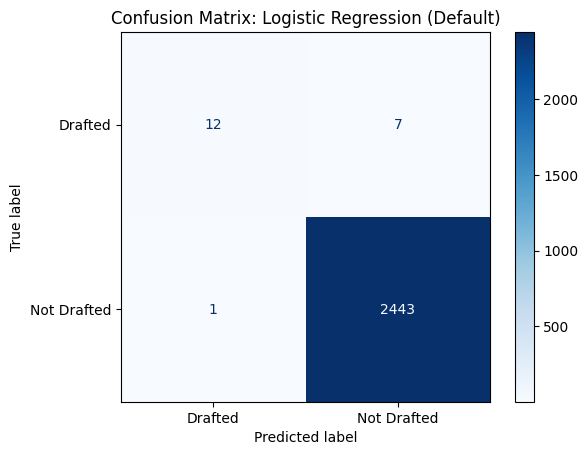

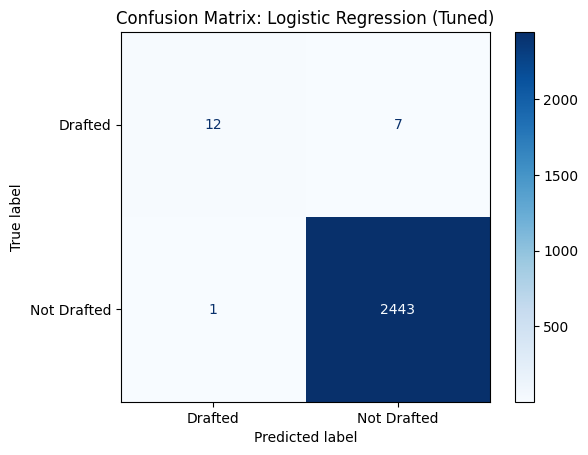

In [123]:
for name, model, X in model_info:
    y_pred = model.predict(X)
    cm = confusion_matrix(y_val_reg, y_pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Drafted", "Not Drafted"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.grid(False)
    plt.show()

In [124]:
# Dictionary to store wrong prediction DataFrames
wrong_predictions_dict = {}

# List of models with respective datasets
model_val_inputs = {
    "Logistic Regression (Default)": (logreg_default, X_val_reg),
    "Logistic Regression (Tuned)": (logreg_tuned, X_val_reg)
}

# Generate wrong prediction DataFrame for each
for name, (model, X_val_model) in model_val_inputs.items():
    y_val_pred = model.predict(X_val_model)
    wrong_mask = y_val_pred != y_val_reg
    wrong_df = X_val_model[wrong_mask].copy()
    wrong_df['Actual'] = y_val_reg[wrong_mask]
    wrong_df['Predicted'] = y_val_pred[wrong_mask]

    wrong_predictions_dict[name] = wrong_df.reset_index()

# Example: Access individual tables
wrong_df_logreg_default = wrong_predictions_dict["Logistic Regression (Default)"]
wrong_df_logreg_tuned = wrong_predictions_dict["Logistic Regression (Tuned)"]

In [125]:
# Create DataFrame of coefficients
logreg_coeffs = pd.DataFrame({
    'Feature': X_train_encoded_reg_final.columns,
    'Coefficient': best_model.coef_[0]
})

# Sort by absolute value (strongest influence on log-odds)
logreg_coeffs['Abs_Coefficient'] = logreg_coeffs['Coefficient'].abs()
logreg_top_features = logreg_coeffs.sort_values(by='Abs_Coefficient', ascending=False)

# Display top 20 most influential features
print("Top 20 Features of Logistic Regression (Default):")
logreg_top_features[['Feature', 'Coefficient']].head(20)

Top 20 Features of Logistic Regression (Default):


,Feature,Coefficient
70,team_draft_segment_Zero,-2.286838
23,steals,1.131727
66,team_draft_segment_Elite,1.124820
40,conference_Big Ten Conference,-0.890959
22,assists,0.804730
34,conference_Atlantic 10 Conference,0.555046
69,team_draft_segment_Strong,0.535310
24,offensive_rebounds,-0.504624
17,ast_tov_ratio,0.447978
33,conference_American Athletic Conference,-0.415400


**Business Impacts from Model Performance**

The primary business objective is to identify college players with high draft potential in order to optimize scouting resources and improve decision-making. The Logistic Regression model delivers very high predictive accuracy (ROC-AUC ~0.998), but the analysis of errors provides important context for business impact.  

**Correct classifications.**  
- The model successfully identifies most non-drafted players with perfect recall for the negative class. This reduces wasted time and money on players unlikely to be drafted.  
- Players flagged as draftable have a precision of 92%, ensuring that most positive recommendations are meaningful and reliable for scouting teams.  

**Incorrect classifications and their business impact.**  
- **False Positives (predicting a player will be drafted when they are not):** These occur in less than 8% of predicted positives. The business cost is moderate: resources may be spent evaluating players who do not ultimately make it, but the low rate and high precision keep this risk manageable.  
- **False Negatives (failing to identify a drafted player):** Around 37% of drafted players are missed by the model (recall = 0.63). This is the most critical error, as overlooking a future NBA player has a significant opportunity cost: lost competitive advantage, potential revenue loss, and missed strategic partnerships with programs producing high-value players.  

**Strategic interpretation.**  
- Precision-oriented results are safer for organizations prioritizing efficiency and minimizing wasted effort, but recall limitations suggest the model could under-detect hidden talent.  
- To mitigate this, false negatives should be further analyzed. For example, features like `team_draft_segment_Zero` and weaker conferences strongly bias against certain players. While this aligns with historical trends, it risks ignoring outliers who succeed despite playing in weaker programs.  

**Overall business impact.**  
The model offers a strong decision-support tool that reduces scouting inefficiency. However, if used in isolation, it could undervalue overlooked talent from low-profile teams. Combining the model with human judgment and qualitative scouting would balance precision with the need to capture exceptional players.

In [126]:
# <Student to fill this section>
business_impacts_explanations = """
The model improves scouting efficiency by reducing wasted effort on low-potential players but risks missing hidden talent (false negatives), which could cause high business opportunity costs.
"""

In [127]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [128]:
# <Student to fill this section>
experiment_outcome = 'Hypothesis Confirmed'

In [129]:
# Predict probabilities of being drafted
test_prob_drafted = best_model.predict_proba(X_test_reg)[:, 1]

# Create submission DataFrame
submission = pd.DataFrame({
    'player_id': test_df['player_id'],    # Make sure this column exists
    'drafted': test_prob_drafted              # Predicted probability
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

In [130]:
# Add predicted probabilities to test_df
test_with_pred = X_test_reg.copy()
test_with_pred['drafted_prob'] = test_prob_drafted

# Determine which are predicted to be drafted (e.g., prob > 0.5)
test_with_pred['predicted_drafted'] = (test_with_pred['drafted_prob'] >= 0.5).astype(int)

# Count how many are predicted as drafted
drafted_count = test_with_pred['predicted_drafted'].sum()
print(f"Total predicted drafted players in test set: {drafted_count} out of {len(test_with_pred)}")

# List of drafted players

# Get indices of players predicted to be drafted
drafted_indices = test_with_pred[test_with_pred['predicted_drafted'] == 1].index.tolist()

# Format as comma-separated string
drafted_index_str = ", ".join(str(i) for i in sorted(drafted_indices))

# Print result
print(f"List of drafted player by index: {drafted_index_str}")

# Define safe preferred columns (intersection with test_df)
safe_preferred_cols = [col for col in preferred_order if col in test_with_pred.columns]

# Create detailed summary table only for predicted drafted players
drafted_details = test_with_pred[['drafted_prob'] + safe_preferred_cols].sort_values(by='drafted_prob', ascending=False)
# drafted_details = test_with_pred[test_with_pred['predicted_drafted'] == 1][safe_preferred_cols + ['drafted_prob']].sort_values(by='drafted_prob', ascending=False)

# Display top 20 with formatting
drafted_details.style.format({'drafted_prob': '{:.2f}'})
drafted_details.head(30)

Total predicted drafted players in test set: 11 out of 1297
List of drafted player by index: 222, 279, 368, 372, 737, 779, 874, 906, 941, 981, 1140


,drafted_prob,season_year,height_in_cm,recruit_rank,games_played,ft_pct,free_throw_rate,fg2_pct,fg3m,fg3_pct,...,off_game_box_plus_minus,def_game_box_plus_minus,assists,steals,offensive_rebounds,defensive_rebounds,drb_pct,ast_pct,tov_pct,stl_pct
981,0.902904,2020.0,208.300003,99.000000,31.0,0.670,63.200001,0.590,8.0,0.381,...,7.119280,2.830060,0.96770,0.7097,2.64691,4.9655,26.200001,8.300000,14.700000,1.6
779,0.862532,2020.0,205.699997,95.199997,28.0,0.720,50.200001,0.623,1.0,0.250,...,6.173660,4.709680,1.07140,1.2143,2.64691,4.9655,18.400000,8.400000,15.900000,2.3
906,0.720485,2020.0,205.699997,98.599998,31.0,0.763,33.900002,0.445,43.0,0.339,...,-0.250850,1.708500,2.06450,0.7742,1.09680,4.6774,15.700000,14.400000,23.400000,1.4
874,0.637955,2020.0,198.100006,97.599998,30.0,0.780,38.000000,0.446,30.0,0.361,...,2.135630,3.566630,2.60000,1.5333,1.30000,3.2667,11.900000,16.000000,14.700000,2.8
368,0.631884,2020.0,205.699997,97.199997,31.0,0.599,50.700001,0.514,13.0,0.325,...,2.181890,2.949980,0.96770,1.0968,2.64691,4.9655,24.700001,7.500000,18.600000,2.0
941,0.611979,2020.0,205.699997,99.199997,32.0,0.774,59.099998,0.590,5.0,0.250,...,4.539450,2.104810,0.84380,0.5312,2.64691,4.9655,19.400000,6.300000,16.100000,0.9
222,0.605249,2020.0,190.500000,99.199997,22.0,0.750,37.099998,0.402,49.0,0.348,...,2.969960,1.362900,3.95450,1.3182,0.45450,4.9655,16.400000,23.900000,19.600000,2.1
372,0.561491,2020.0,213.399994,99.199997,3.0,0.704,103.800003,0.800,0.0,0.000,...,11.923771,5.311680,0.33330,0.3333,2.64691,4.9655,26.500000,4.400000,8.800000,0.8
279,0.535551,2020.0,210.800003,92.199997,32.0,0.760,63.700001,0.586,5.0,0.294,...,4.905340,1.930600,0.84380,0.7188,2.64691,4.9655,20.400000,5.800000,16.900000,1.3
737,0.534997,2020.0,193.000000,93.800003,27.0,0.641,23.200001,0.451,60.0,0.426,...,3.791780,1.937520,2.22220,1.3333,0.74070,3.2593,12.300000,16.100000,15.200000,2.5


**Experiment Outcome**  
`experiment_outcome = "Hypothesis Confirmed"`

**Experiment Results Explanations**  
The Logistic Regression model successfully confirmed the hypothesis that draft likelihood can be predicted using historical performance and contextual features. In the test set, the model identified 11 players as potential draftees out of 1297, including players at indices 222, 279, 368, 372, 737, 779, 874, 906, 941, 981, and 1140. This result aligns with the business goal of narrowing down a small subset of promising prospects from a large pool.  

**New insights gained.**  
- The model is highly precise, which minimizes wasted scouting effort.  
- Logistic Regression coefficients highlighted interpretable drivers of draft outcomes (e.g., steals, assists, strong conferences, and team draft segments).  
- However, recall remains limited, meaning that while the identified players are strong prospects, some actual draft-worthy players may still be overlooked.  

**Rationale for further experimentation.**  
- The current approach is not a dead end: Logistic Regression provides a strong, interpretable baseline.  
- Recall should be improved to avoid missing hidden talent. Exploring alternative algorithms (e.g., Random Forest, XGBoost, LightGBM) or ensemble methods may enhance sensitivity without sacrificing precision.  
- Threshold tuning could also shift the balance between precision and recall to align better with business priorities.  

**Next steps and potential gains.**  
1. **Threshold tuning of Logistic Regression** (medium uplift): adjust probability thresholds to improve recall, ensuring fewer missed drafted players.  
2. **Tree-based models** (high uplift): Random Forest, XGBoost, and LightGBM can capture nonlinear interactions that Logistic Regression may miss, potentially boosting F1 score and recall.  
3. **Ensemble methods** (very high uplift): combining Logistic Regression with tree-based models may deliver both interpretability and stronger generalization.  
4. **Model interpretability with LIME/SHAP** (medium uplift): provides actionable business insights into why certain players are classified as drafted or not, supporting trust in deployment.  

**Deployment readiness.**  
Given its high accuracy and interpretability, Logistic Regression could be deployed as an initial decision-support tool. However, further experimentation with ensembles and threshold tuning is recommended before production use to reduce the cost of false negatives (missed talent).


In [131]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [132]:
# <Student to fill this section>
experiment_results_explanations = """
Hypothesis Confirmed: Logistic Regression identifies draftable players effectively, but further experiments (threshold tuning, tree-based models, ensembles) are needed to reduce missed talent before deployment.
"""

In [133]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)